# 06 - The gear train seen from both ends

## Purpose

This notebook continues a series working toward an accurate,
mathematically proven servo control loop, built on empirical data. Notebook
01 found a 20 to 30% ripple on the pot-derived speed that the back-EMF does
not carry, and left the gear ratio and the pot's linearity open. Notebooks
03 to 05 expressed every constant in wiper units for that reason. This
notebook reads the motor side of the gear train through the commutation
ripple of the winding current, which gives a speed and angle signal that
owes nothing to the pot, and compares the two ends.

This notebook has three jobs:

1. Build the ripple tachometer. Extract the ripple frequency of every
   steady drive step, show it against the pot-derived speed, measure the
   motor-to-wiper coupling in ripple cycles per wiper volt with its
   spread, and characterize the ripple line (section 5).
2. Test the pot's linearity. Integrate the ripple to a motor-side angle
   inside each step, compare it with the pot trace, and decide whether the
   speed ripple of notebook 01 is a periodic error on the pot side and
   whether the coupling depends on position (section 6).
3. Measure the gear play. From the reversal recordings, find the lag
   between the motor reversing and the output reversing, express the play
   as wiper volts of motor travel during which the pot stands still, per
   direction and amplitude, and look for slip outside reversals (section
   7).

Job 1 works, and it lands on the same coupling the retired run found. Jobs
2 and 3 do not, and the reason is a defect on this board rather than
anything about the servo. Both of them read the pot at the scale of a few
ADC counts, and on this board the position channel never produces about
half its codes and sticks on two of them. Section 4.1 measures that before
any of the analysis, and sections 6 and 7 show where it lands. I report
the numbers this session gives, say why I do not believe two of the three,
and leave the retired run's answers standing on those two.

The dataset is one session on a laptop USB port, captured on the current
measurement chain (chain 3 in notebook 00), described in section 3.
Position stays in pot wiper volts, speed in wiper volts per second,
current in amperes with the bias of each recording subtracted. The true
gear ratio needs the pot's volts per turn, which is left to a later
notebook. Everything here is in ripple cycles per wiper volt.

An earlier run of all three campaigns on a 2-cell battery and the previous
chain (chain 2) is retired and is not an input anywhere below. Both the
chain and the supply changed between the two runs, so where an old number
is quoted for comparison I say which of the two could have moved it. The
motor turns about half as fast on USB as it did on the battery, so every
ripple line in this notebook sits at about half the frequency the retired
run showed.


## 1. Test setup

The device under test is an SG90-class hobby servo with its stock
electronics replaced by a custom controller board. The signal chain is the
one described in notebooks 00 and 01 (chain 3). The points this notebook
depends on:

- A brushed DC motor driven by an H-bridge with 20 kHz center-aligned PWM
  under slow decay, so the OFF portion of every period is brake. **Duty**
  is the fraction of each period in the drive state.
- A gear train couples the motor to the output shaft, and a potentiometer
  on the output shaft is read by the MCU's 12-bit ADC. Position stays in
  wiper volts.
- A 60 mOhm shunt in the motor return path, amplified with gain 15.0, gives
  the motor current. The crest scan samples it once per period at the
  center of the drive window. The amplifier output includes an offset,
  measured from the baseline segment of each recording and subtracted
  throughout.
- Both motor terminals are read through 6.8 kOhm / 3.3 kOhm dividers whose
  bottom legs return to a bias node $V_B$ of about 0.63 V, with a 150 pF
  reservoir capacitor on each tap. Their difference is bias-free once each
  terminal's own rest reading is taken out, $v_A - v_B = r\,(\text{tap}_A -
  \text{tap}_B)$ in ADC volts with $r = 3.06$ (notebook 00, section 2).
  Under drive it reads the applied terminal voltage. On this chain the two
  taps do not read the same bias at rest, an 18-count split that notebook
  00 (section 5.3) leaves open, so every terminal reading below carries its
  own terminal's rest value. The only place a terminal enters this notebook
  is the ripple amplitude of section 5.3, which is a spectral line and
  therefore free of both biases.

**The ripple mechanism.** The motor has three windings and two brushes.
Each time a brush crosses a gap between commutator segments the circuit
through the winding changes, and the winding current takes a small step.
The steps recur at a fixed number of pulses per motor revolution, taken
here as six, an input from the motor's construction (section 2), so the
shunt current carries a ripple whose frequency is that number times the
motor's revolutions per second. The stream samples the current once per
PWM period, synchronous with the PWM, so the 20 kHz chop cancels and the
ripple appears as a clean spectral line. The line frequency is a motor-side
speed signal independent of the pot, and its integral is a motor-side
angle. In wiper units the gear train appears as ripple cycles per wiper
volt.

**The board is a hacked rig.** The board under this session is a
development board that has been reworked by hand several times (the shunt,
the dividers, the bias return, the reservoir capacitors, a repaired
amplifier pad). I know of two defects on it that the next board revision
does not have, and both of them land on this notebook rather than on the
earlier ones.

- The bus telemetry stream couples into the current amplifier's output, so
  a shunt sample taken while a frame is going out on the wire reads a few
  counts off. One frame carries 16 samples, so the coupling is periodic at
  a sixteenth of the sample rate and shows up in a current spectrum as a
  line at 1250 Hz and its harmonics. That is right inside the band this
  notebook searches for the ripple line. Section 5.1 measures it against
  the ripple line rather than filtering it out.
- The ADC drops codes on the position channel at its current clock. Every
  pot-derived number below carries that, and section 6 is a comparison of
  the pot against the motor, so it is worth saying out loud that the pot
  side of that comparison is the side with the known defect.

Neither one is coded around in the firmware, and I do not code around
them here either. Where a defect could be mistaken for a result I measure
it and show the size.

Power is a laptop USB port. The rail reaching the motor is about 4.5 V
(notebook 00, section 6.2) against the 7.4 V of the retired battery run,
so the motor runs at about half the speed and every ripple line sits at
about half the frequency. The three campaigns of section 3 were captured
in one session.


## 2. Constants and unit conversions

All conversions from ADC counts to physical units use the constants below,
per chain, the same table as notebooks 00 and 05, with one input added.
The shunt, the divider legs, the amplifier gain, and VDD are written into
every recording's `meta.json` by the capture tool (the `sense` block), and
the loader in section 3 checks each recording against this table and
against the supply, and stops with an error if they disagree. The bias
divider, the reservoir capacitor, and the sampling floors are not in the
metadata, so this table is the only record of them. Every recording in
this notebook is on chain 3. Chain 2 stays in the table as the record of
what the retired battery run was captured on.

| Quantity | Chain 3 (this dataset) | Chain 2 (retired battery run) |
|---|---|---|
| ADC resolution | 12 bit (0..4095 counts) | same |
| ADC reference | VDD, nominal 3.300 V | same |
| ADC clock | 48 MHz | slower, not recorded here |
| Motor terminal divider | 6.8 kOhm top / 3.3 kOhm bottom, bottom leg returned to the terminal bias | 20 kOhm / 10 kOhm, same return |
| Terminal tap reservoir | 150 pF per tap | none |
| Terminal bias $V_B$, nominal | 200 Ohm / 47 Ohm from VDD, 0.628 V | 430 Ohm / 100 Ohm from VDD, 0.623 V |
| Terminal bias $V_B$, measured | per recording and per terminal, from the segment-0 baseline (section 3) | per recording |
| Current shunt | 60 mOhm | 33 mOhm |
| Current amplifier gain | 15.0 | 15.0 |
| Control period | 50 us (20 kHz) | same |
| PWM counter | 1200 timer ticks per half period, center aligned | same |
| Duty encoding | signed, 32767 = 100% | same |
| Current sampling floor | 160 timer ticks = 13.3% duty | 160 ticks = 13.3% |
| Voltage sampling floor | 120 timer ticks = 10.0% duty | 210 ticks = 17.5% |
| Commutation pulses per motor revolution | 6, input from the motor's construction (three windings, two brushes) | same motor |

Every drive step in this notebook is at 20% duty or above, so every
crest-scan current and terminal sample of a drive step is settled by both
floors.

The shunt went from 33 to 60 mOhm in the rebuild, so one ADC count is now
0.90 mA where it was 1.63 mA. Every current in this notebook is smaller
than in the retired run for the supply, and every current expressed in
counts is larger for the shunt. The ripple amplitude in milliamperes is
the number to compare across the two runs.

The pulses-per-revolution figure is a stated input and nothing in the data
confirms it. Every result is therefore expressed in ripple cycles, and the
one column that converts cycles to motor revolutions is labeled as
derived from that input. The ripple frequency $f_r$ in cycles per second,
the coupling $C$ in cycles per wiper volt, and the motor-side angle in
cycles are all measured.

Two caveats carry over from notebook 00. The ADC reference is the design
value, so every voltage and current scales with the true VDD of this unit.
The divider, shunt and gain are design values with unmeasured tolerances.
The pot wiper scale is the same nominal VDD, so a ratio of wiper volts to
anything in wiper volts is unaffected.

The derived conversion factors:


In [1]:
from pathlib import Path

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import get_window, detrend, butter, sosfiltfilt, medfilt, find_peaks

# --- constants shared by both chains ---
ADC_COUNTS = 4096           # 12-bit converter
TICK_HZ = 20_000            # control / sample rate
PWM_HALF_TICKS = 1200       # timer ticks per PWM half period
Q15 = 32767                 # duty full scale as encoded on the wire
PULSES_PER_REV = 6          # commutation pulses per motor revolution, stated input
FRAME_SAMPLES = 16          # samples per telemetry frame, the period of the bus coupling

# --- per-chain constants (the table above) ---
# shunt/divider/gain/vdd are cross-checked against meta.json `sense`;
# bias divider and floors exist only here.
CHAIN_TABLE = {
    3: dict(label="chain 3", shunt_mohm=60, div_top=6_800, div_bot=3_300,
            gain_milli=15_000, vdd_mv=3_300, bias_top=200, bias_bot=47,
            floor_i_ticks=160, floor_v_ticks=120),
    2: dict(label="chain 2, retired", shunt_mohm=33, div_top=20_000, div_bot=10_000,
            gain_milli=15_000, vdd_mv=3_300, bias_top=430, bias_bot=100,
            floor_i_ticks=160, floor_v_ticks=210),
}
# which chain each campaign folder was captured on, and the supply it ran on
CAMPAIGN_CHAIN = {"ripple-usb": 3, "reversal-usb": 3, "usb": 3}
SUPPLY = "usb"

class Chain:
    # Conversion factors for one measurement chain.
    def __init__(self, n):
        c = CHAIN_TABLE[n]
        self.n, self.label = n, c["label"]
        self.vdd_v = c["vdd_mv"] / 1e3
        self.v_adc_per_count = self.vdd_v / ADC_COUNTS                  # volts at the ADC pin
        self.div_ratio = (c["div_top"] + c["div_bot"]) / c["div_bot"]  # r in the tap formula
        self.v_term_per_count = self.v_adc_per_count * self.div_ratio  # terminal volts per tap count
        self.vb_nom_v = self.vdd_v * c["bias_bot"] / (c["bias_top"] + c["bias_bot"])
        self.shunt_ohm = c["shunt_mohm"] / 1e3
        self.amp_gain = c["gain_milli"] / 1e3
        self.a_per_count = self.v_adc_per_count / (self.amp_gain * self.shunt_ohm)
        self.floor_i_pct = c["floor_i_ticks"] * 100.0 / PWM_HALF_TICKS
        self.floor_v_pct = c["floor_v_ticks"] * 100.0 / PWM_HALF_TICKS
        self.sense = {"shunt_r_mohm": c["shunt_mohm"], "vmotor_div_top": c["div_top"],
                      "vmotor_div_bot": c["div_bot"], "gain_milli": c["gain_milli"],
                      "vdd_mv": c["vdd_mv"]}

    def check_meta(self, meta, where):
        # Fail loudly if a recording was captured on different parts than
        # this table says. The keys are the capture tool's `sense` block.
        got = {k: meta["sense"][k] for k in self.sense}
        if got != self.sense:
            raise ValueError(f"{where}: meta.json sense {got} != {self.label} table {self.sense}")
        if meta["supply"] != SUPPLY:
            raise ValueError(f"{where}: supply {meta['supply']!r}, expected {SUPPLY!r}")

    def term_V(self, tap_counts, vb_counts):
        # Absolute terminal voltage from a tap reading: Vt = r tap - (r-1) VB.
        return (self.div_ratio * tap_counts - (self.div_ratio - 1) * vb_counts) * self.v_adc_per_count

CHAINS = {n: Chain(n) for n in CHAIN_TABLE}
CH = CHAINS[CAMPAIGN_CHAIN["ripple-usb"]]   # every number in this notebook is on this chain
DT = 1.0 / TICK_HZ
NYQUIST_HZ = TICK_HZ / 2
BUS_LINE_HZ = TICK_HZ / FRAME_SAMPLES       # the board's bus coupling, section 1
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

rows = []
for ch in CHAINS.values():
    rows += [
        {"chain": ch.label, "quantity": "pot wiper", "value": ch.v_adc_per_count * 1e3, "unit": "mV per count"},
        {"chain": ch.label, "quantity": "terminal divider ratio r", "value": ch.div_ratio, "unit": ""},
        {"chain": ch.label, "quantity": "motor terminal difference", "value": ch.v_term_per_count * 1e3, "unit": "mV per count"},
        {"chain": ch.label, "quantity": "terminal bias, nominal", "value": ch.vb_nom_v * 1e3, "unit": "mV"},
        {"chain": ch.label, "quantity": "motor current", "value": ch.a_per_count * 1e3, "unit": "mA per count"},
        {"chain": ch.label, "quantity": "drive window settled, current", "value": ch.floor_i_pct, "unit": "% duty and above"},
        {"chain": ch.label, "quantity": "drive window settled, voltage", "value": ch.floor_v_pct, "unit": "% duty and above"},
        {"chain": ch.label, "quantity": "ripple frequency ceiling (Nyquist)", "value": NYQUIST_HZ, "unit": "Hz"},
        {"chain": ch.label, "quantity": "bus coupling line (sample rate / 16)", "value": BUS_LINE_HZ, "unit": "Hz"},
        {"chain": ch.label, "quantity": "motor revolutions per ripple cycle (from the stated input)", "value": 1 / PULSES_PER_REV, "unit": "rev per cycle"},
    ]
pd.DataFrame(rows).set_index(["quantity", "unit", "chain"])["value"].unstack("chain").round(4)


,chain,"chain 2, retired",chain 3
quantity,unit,,
bus coupling line (sample rate / 16),Hz,1250.0000,1250.0000
"drive window settled, current",% duty and above,13.3333,13.3333
"drive window settled, voltage",% duty and above,17.5000,10.0000
motor current,mA per count,1.6276,0.8952
motor revolutions per ripple cycle (from the stated input),rev per cycle,0.1667,0.1667
motor terminal difference,mV per count,2.4170,2.4658
pot wiper,mV per count,0.8057,0.8057
ripple frequency ceiling (Nyquist),Hz,10000.0000,10000.0000
"terminal bias, nominal",mV,622.6415,627.9352


## 3. Capture method

Three campaigns enter, all under slow decay on chain 3 at USB, all in the
repository under `notebooks/telemetry/sg90/`, one folder per recording.
Every recording starts with a one-second baseline segment with the bridge
disabled, which gives the current offset and the rest reading of each
terminal.

- **Steady steps** (`ripple-usb/`, five recordings). Segments 1 to 3 are
  120 ms drive steps at 20%, 40% and 60% duty forward, segments 4 to 6 the
  same in reverse. Before every step the servo is repositioned at 15% duty
  toward the far end of travel, so the step has room to run, and the
  mechanism can still be moving from that move when the step begins. The
  last 60% of each step (72 ms) is the settled window.
- **Reversals** (`reversal-usb/`, five recordings). Two passes, forward then
  reverse. Each pass has two triplets. A triplet is a 60 ms drive step at
  the pass direction, then 60 ms at the opposite sign, then 60 ms at the
  pass direction again, each chained to the previous one with no
  repositioning and no gap, so the drive flips sign at a running motor.
  The first triplet is at 20% duty, the second at 40%, and each triplet is
  followed by 200 ms of brake. The schedule in the metadata marks the
  chained steps with a `then:` prefix. Only the first step of a triplet
  follows a repositioning move. The four flips per pass, eight per
  recording, are the reversal events of section 7.
- **Duty grid** (`usb/`, ten recordings, the grid of notebooks 00, 04 and
  05). 80 ms drive steps at 5% to 100% duty in 5% increments, forward then
  reverse. The steps do not settle within 80 ms (notebook 04, section
  6.1), so they enter section 5 and 6 only through the time-resolved
  tracker, and only from 30% to 55% duty, the range in which the tracker
  holds the line over at least 0.15 wiper V of travel. On USB an 80 ms
  step covers about half the travel it covered on the battery, so fewer
  grid steps clear that bar than in the retired run. Section 5.2 reports
  how many.

**Data acceptance.** A recording is accepted only if the host counted zero
dropped frames. Section 4 re-verifies this from the data itself.

Each row is one 50 us sample, with segment number, commanded duty,
direction, tick counter, the firmware's validity flag, position, the
crest-scan shunt (`current_raw`), the trough-scan shunt
(`current_trough`), and the crest-scan terminals (`vmotor_a`,
`vmotor_b`). The `dir` column holds the pass direction and does not flip
inside a reversal triplet, so the direction of every drive step is read
from the sign of its commanded duty.

The segment-0 baseline of every recording gives the shunt amplifier's bias
(mean of `current_raw`) and the rest reading of each terminal (median of
`vmotor_a` and of `vmotor_b`), which are the $V_B$ of terminal A and of
terminal B. The loader also checks each recording's `sense` block and
supply against section 2. The table summarizes all of it per campaign,
with the position noise of the baseline, which sets the resolution of
every pot-based threshold below.


In [2]:
TELEMETRY = Path("telemetry/sg90")

def by_number(paths):
    return sorted(paths, key=lambda p: int(p.name.split("-")[1]))

def load_recording(path):
    # One recording = sweep.csv.gz (per-tick samples) + meta.json (settings).
    # Derived columns: duty_pct (signed percent), mag_pct (rounded magnitude),
    # and the per-recording baseline constants bias (shunt amplifier offset),
    # vb (terminal A rest reading), vb_b (terminal B rest reading).
    df = pd.read_csv(path / "sweep.csv.gz")
    meta = json.loads((path / "meta.json").read_text())
    CH.check_meta(meta, path)
    df["duty_pct"] = df["cmd_duty_q15"] * 100.0 / Q15
    df["mag_pct"] = df["duty_pct"].abs().round().astype(int)
    base = df[df["seg"] == 0]
    df["bias"] = base["current_raw"].mean()
    df["vb"] = base["vmotor_a"].median()
    df["vb_b"] = base["vmotor_b"].median()
    df["pos_noise"] = base["pos"].iloc[4000:].std()
    return df, meta

def load_campaign(name):
    return {d.name: load_recording(d) for d in by_number((TELEMETRY / name).glob("capture-*"))}

ripple = load_campaign("ripple-usb")
reversal = load_campaign("reversal-usb")
grid = load_campaign("usb")
campaigns = {"steady steps": ripple, "reversals": reversal, "duty grid": grid}

def flip_pairs(meta):
    # Segment k (k >= 1) is schedule entry (k - 1). A flip is a chained step
    # ("then:") that follows a drive step. Returns (segment before, segment after).
    sched = meta["schedule"]
    n_per_pass = len(sched)
    pairs = []
    for p in range(len(meta["dirs"])):
        for k, entry in enumerate(sched):
            if entry.startswith("then:") and ":" not in sched[k - 1].replace("then:", ""):
                seg = p * n_per_pass + k + 1
                pairs.append((seg - 1, seg))
    return pairs

rows = []
for cname, recs in campaigns.items():
    vbs = [df["vb"].iloc[0] for df, _ in recs.values()]
    vbb = [df["vb_b"].iloc[0] for df, _ in recs.values()]
    rows.append({
        "campaign": cname,
        "recordings": len(recs),
        "VB_A [counts]": np.mean(vbs),
        "VB_B [counts]": np.mean(vbb),
        "B minus A [counts]": np.mean(vbb) - np.mean(vbs),
        "VB_A spread over recordings [counts]": max(vbs) - min(vbs),
        "VB_A minus nominal [mV]": (np.mean(vbs) * CH.v_adc_per_count - CH.vb_nom_v) * 1e3,
        "current bias [counts]": np.mean([df["bias"].iloc[0] for df, _ in recs.values()]),
        "position noise [counts rms]": np.mean([df["pos_noise"].iloc[0] for df, _ in recs.values()]),
        "flips per recording": len(flip_pairs(next(iter(recs.values()))[1])) if cname == "reversals" else 0,
    })
pd.DataFrame(rows).set_index("campaign").round(3)


,recordings,VB_A [counts],VB_B [counts],B minus A [counts],VB_A spread over recordings [counts],VB_A minus nominal [mV],current bias [counts],position noise [counts rms],flips per recording
campaign,,,,,,,,,
steady steps,5,766.0,784.0,18.0,0.0,-10.797,110.352,1.625,0
reversals,5,765.2,784.0,18.8,1.0,-11.441,108.313,1.320,8
duty grid,10,766.0,784.0,18.0,0.0,-10.797,111.547,1.288,0


Terminal A rests at 766 counts and terminal B at 784 in every recording of
every campaign, the same 18-count split notebook 00 reports and leaves
open. Terminal A sits about 11 mV below the nominal bias and terminal B
about 4 mV above it. Nothing in this notebook reads an absolute terminal
voltage, so the split only has to not be mistaken for signal, and section
5.3 reads the terminals as a spectral amplitude where neither bias
appears.

The shunt amplifier rests at 110 to 112 counts, about 100 mA equivalent
through the 60 mOhm shunt, and every current below has the recording's own
value subtracted.

## 4. Data integrity

The transport turns a corrupted frame into a missing sample. The table
recomputes the missing-sample count of every recording from the tick
column, which increments by one per sample within a segment.


In [3]:
def missing_samples(df):
    missing = 0
    for _, seg in df.groupby("seg"):
        ticks = seg["tick"].to_numpy()
        missing += int(ticks[-1] - ticks[0] + 1 - len(ticks))
    return missing

rows = []
for cname, recs in campaigns.items():
    for name, (df, meta) in recs.items():
        rows.append({"campaign": cname, "recording": name, "samples": len(df),
                     "segments": df["seg"].nunique(), "missing_samples": missing_samples(df)})
integrity = pd.DataFrame(rows).set_index(["campaign", "recording"])
integrity.groupby("campaign").agg(recordings=("samples", "size"), samples=("samples", "sum"),
                                  segments=("segments", "sum"), missing_samples=("missing_samples", "sum"))


,recordings,samples,segments,missing_samples
campaign,,,,
duty grid,10,840000,410,0
reversals,5,252000,85,0
steady steps,5,172000,35,0


Every recording of every campaign has zero missing samples.

### 4.1 Rig caveat: the position channel drops codes

Section 1 lists the second defect of this board, the ADC dropping codes on
the position channel at its current clock. This notebook compares the pot
against the motor, so I want the size of that defect on the table before
any of the comparison. Three numbers say it. How many codes inside the
covered span never appear at all, how much of the recording sits on the
single most common code, and how much of it sits on the two codes the
channel sticks hardest on. The retired chain 2 duty grid is still in the
repository, so I run the same count over it as a comparison. It is a
comparison only and no fit below takes it as an input.


In [4]:
POT_STICKY = (1024, 3071)   # the two codes the position channel sticks on

def code_stats(dfs, label):
    p = np.concatenate([df[df["seg"] > 0]["pos"].to_numpy() for df in dfs])
    span = int(p.max() - p.min() + 1)
    used = int(len(np.unique(p)))
    vc = pd.Series(p).value_counts()
    return {"set": label, "samples": len(p), "code span": span, "codes used": used,
            "codes never seen [%]": (span - used) / span * 100,
            "most common code": int(vc.index[0]),
            "samples on it [%]": vc.iloc[0] / len(p) * 100,
            "samples on 1024 or 3071 [%]": float(np.isin(p, POT_STICKY).mean()) * 100}

rows = [code_stats([df for df, _ in recs.values()], f"chain 3, {cname}")
        for cname, recs in campaigns.items()]
rows.append(code_stats([pd.read_csv(d / "sweep.csv.gz", usecols=["seg", "pos"])
                        for d in by_number((TELEMETRY / "2s").glob("capture-*"))],
                       "chain 2 duty grid, retired, comparison only"))
pd.DataFrame(rows).set_index("set").round(2)


,samples,code span,codes used,codes never seen [%],most common code,samples on it [%],samples on 1024 or 3071 [%]
set,,,,,,,
"chain 3, steady steps",72000,2290,1107,51.66,1024,7.95,14.38
"chain 3, reversals",152000,2300,508,77.91,1024,11.05,16.47
"chain 3, duty grid",640000,2365,1279,45.92,1024,8.81,14.96
"chain 2 duty grid, retired, comparison only",640000,2467,2466,0.04,938,0.36,0.19


The position channel on chain 3 never produces 46% of the codes in the
span the duty grid covers and 52% of the span the steady steps cover. The
reversals reach 78%, but they only ever visit a narrow band of travel so
that figure is not comparable. It parks on code 1024 for 8 to 11% of every
recording, and on 1024 or 3071 together for 14 to 16%. The same count over
the retired chain 2 grid finds one missing code out of 2467 and the most
common code holding 0.4% of the samples. Same pot, same mechanism, so this
is the converter. *Hypothesis (not tested here): both sticky codes sit on
a power-of-two boundary, 1024 is $2^{10}$ and 3071 is $3 \times 2^{10} -
1$, and those are the codes a successive-approximation converter decides
first, so a sample window too short for the comparator to settle would
fail there before anywhere else. Testing it needs the aperture varied on
the bench.*

In wiper volts the two sticky codes sit at 0.825 V and 2.474 V. Keep those
two numbers in mind for section 6, which reads the pot in 20 mV bins, and
for section 7, whose reversals happen to take place right on top of them.
The coupling of section 5 is safe from this, since it divides a cycle
count by a travel of hundreds of millivolts and a few counts of code error
at each end is under a percent of that.

## 5. The ripple tachometer

### 5.1 Spectra of the steady steps

For every steady step the settled window is the last 60% of the step. The
current in that window is detrended, weighted with a Hann window and
transformed with eightfold zero padding. The ripple line is the largest
peak between 200 Hz and 6 kHz, with parabolic interpolation of the peak
bin. The lower edge keeps the mechanical rise and the pot's own periodic
error out of the search. The upper edge is well above the highest ripple
frequency this session reaches, since the motor runs at about half the
battery run's speed, and I left it where the battery run had it so the
pipeline is the same one.

The amplitude of a line is the peak height with the window's coherent gain
removed, in counts and in milliamperes. The width of a line is its full
width at half amplitude, compared with the width the 72 ms Hann window
gives a pure tone through the same pipeline (the last column). Where a
peak at six, three or two times the largest peak's frequency is at least
half as tall, the largest peak is a sub-line of the family in section 5.3
and the upper peak is taken as the line. The harmonic content is read at fixed
ratios to the line, $2 f_r$ above it and $f_r / 2$, $f_r / 3$, $f_r / 6$
below it, as the peak within 5% of each frequency relative to the line.
The figure shows the six settled spectra of one recording. The table pools
the five recordings by duty magnitude and direction.


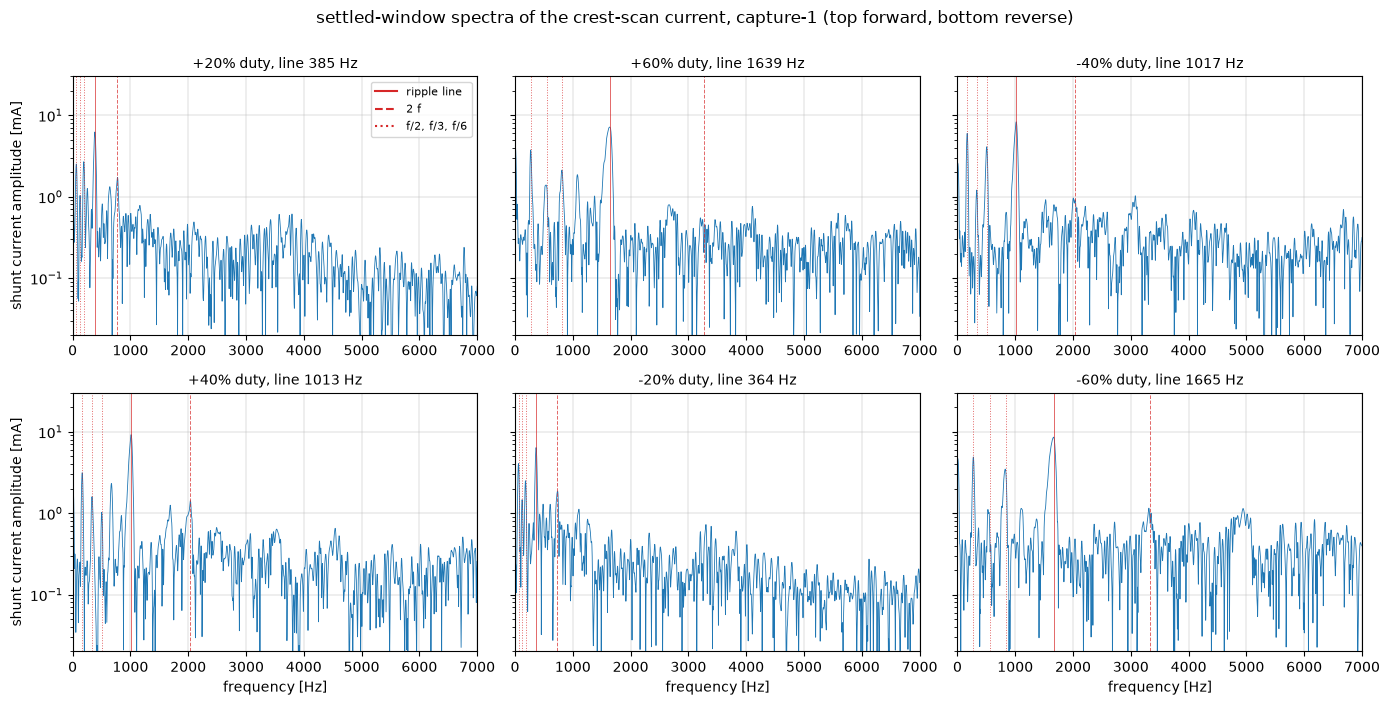

f_line_Hz                     width_Hz                   width_pct               amp_mA               line_over_floor                 mean_current_A               pot_speed_Vps  \
                       mean       min       max     mean      min      max      mean    min    max   mean    min    max            mean     min     max           mean    min    max          mean   
mag_pct direction                                                                                                                                                                                    
20      forward     387.827   373.440   400.301   36.111   32.986   38.194     9.323  8.240  9.916  5.951  5.777  6.223          32.532  30.278  35.633          0.043  0.042  0.045         1.490   
        reverse     380.090   364.351   389.319   31.944   31.250   32.986     8.406  8.134  8.646  6.487  6.390  6.811          35.065  32.941  37.826          0.042  0.042  0.043        -1.151   
40      forward    1038.455  1012.723  1055.869   64.236   59.028   69.444     6.182  5.721  6.631  8.272  7.797  9.206          38.308  35.921  39.918          0.068  0.067  0.069         3.844   
        reverse    1039.427  1017.485  1052.652   60.417   59.028   62.500     5.813  5.634  5.972  8.186  7.969  8.449          33.761  32.013  35.541          0.067  0.066  0.068        -4.242   
60      forward    1671.214  1638.515  1685.554  107.292   97.222  112.847     6.422  5.768  6.781  7.442  6.935  7.987          26.556  20.757  30.281          0.088  0.087  0.090         6.421   
        reverse    1690.316  1664.518  1704.695  119.097  114.583  123.264     7.045  6.884  7.253  7.742  7.387  8.584          22.451  20.576  24.479          0.087  0.085  0.088        -6.772   

                                tone_width_Hz  
                     min    max         floor  
mag_pct direction                              
20      forward    1.324  1.700          24.3  
        reverse   -1.279 -1.025          24.3  
40      forward    3.735  3.927          24.3  
        reverse   -4.295 -4.144          24.3  
60      forward    6.337  6.463          24.3  
        reverse   -6.817 -6.674          24.3

In [5]:
F_LO, F_HI = 200.0, 6000.0
SETTLED = 0.6

def line_spectrum(x, nfft_mult=8):
    # Amplitude spectrum in the units of x, coherent gain of the Hann window removed.
    x = detrend(x)
    w = get_window("hann", len(x))
    nfft = nfft_mult * len(x)
    return np.fft.rfftfreq(nfft, DT), np.abs(np.fft.rfft(x * w, nfft)) * 2 / w.sum()

def interp_peak(f, X, lo, hi):
    m = (f >= lo) & (f <= hi)
    Xm, fm = X[m], f[m]
    i = int(np.argmax(Xm))
    d = 0.0
    if 0 < i < len(Xm) - 1:
        a, b, c = np.log(Xm[i - 1]), np.log(Xm[i]), np.log(Xm[i + 1])
        d = 0.5 * (a - c) / (a - 2 * b + c)
    return fm[i] + d * (f[1] - f[0]), Xm[i]

def half_width(f, X, f0):
    m = (f >= 0.7 * f0) & (f <= 1.3 * f0)
    fm, Xm = f[m], X[m]
    i = int(np.argmax(Xm))
    above = Xm >= Xm[i] / 2
    lo = i
    while lo > 0 and above[lo - 1]:
        lo -= 1
    hi = i
    while hi < len(Xm) - 1 and above[hi + 1]:
        hi += 1
    return fm[hi] - fm[lo]

def settled_line(f, X):
    # Largest peak in the band. Where a peak at six, three or two times that
    # frequency is at least half as tall, the lower peak is a sub-line of the
    # family in section 5.3 and the upper one is the ripple line.
    f0, a0 = interp_peak(f, X, F_LO, F_HI)
    for k in (6, 3, 2):
        if k * f0 * 1.05 <= F_HI:
            fk, ak = interp_peak(f, X, k * f0 * 0.95, k * f0 * 1.05)
            if ak >= 0.5 * a0:
                return fk, ak
    return f0, a0

def tone_width():
    # Width of a pure tone through the same window and search, the resolution floor.
    n = int(round(2400 * SETTLED))
    x = np.sin(2 * np.pi * 1000.0 * np.arange(n) * DT)
    f, X = line_spectrum(x)
    return half_width(f, X, 1000.0)

def settled(seg):
    n0 = int(len(seg) * (1 - SETTLED))
    return seg.iloc[n0:]

def pot_speed(seg):
    # Least-squares slope of the wiper over the window, in wiper V/s.
    p = seg["pos"].to_numpy() * CH.v_adc_per_count
    return np.polyfit(np.arange(len(p)) * DT, p, 1)[0]

def step_line(seg):
    st = settled(seg)
    x = st["current_raw"].to_numpy().astype(float) - st["bias"].iloc[0]
    f, X = line_spectrum(x)
    fr, amp = settled_line(f, X)
    noise = np.median(X[(f >= F_LO) & (f <= F_HI)])
    ratios = {}
    for label, k in [("2f", 2.0), ("f/2", 0.5), ("f/3", 1 / 3), ("f/6", 1 / 6)]:
        _, a = interp_peak(f, X, k * fr * 0.95, k * fr * 1.05)
        ratios[label] = a / amp
    vt = CH.div_ratio * (st["vmotor_a"].to_numpy() - st["vmotor_b"].to_numpy()).astype(float)
    ft, Xt = line_spectrum(vt)
    _, amp_t = interp_peak(ft, Xt, fr * 0.97, fr * 1.03)
    xb = st["current_trough"].to_numpy().astype(float) - st["bias"].iloc[0]
    fb, Xb = line_spectrum(xb)
    _, amp_b = interp_peak(fb, Xb, fr * 0.97, fr * 1.03)
    return {
        "duty_pct": seg["duty_pct"].iloc[0],
        "mag_pct": int(seg["mag_pct"].iloc[0]),
        "f_line_Hz": fr,
        "amp_counts": amp,
        "amp_mA": amp * CH.a_per_count * 1e3,
        "noise_floor_counts": noise,
        "width_Hz": half_width(f, X, fr),
        "width_pct": half_width(f, X, fr) / fr * 100,
        "line_over_floor": amp / noise,
        "mean_current_A": x.mean() * CH.a_per_count,
        "pot_speed_Vps": pot_speed(st),
        "terminal_ripple_mV": amp_t * CH.v_adc_per_count * 1e3,
        "brake_window_ripple_counts": amp_b,
        **{f"ratio_{k}": v for k, v in ratios.items()},
    }

lines = []
for name, (df, meta) in ripple.items():
    for seg_id, seg in df[df["seg"] > 0].groupby("seg"):
        row = step_line(seg)
        row.update({"recording": name, "seg": seg_id})
        lines.append(row)
lines = pd.DataFrame(lines)
lines["direction"] = np.where(lines["duty_pct"] > 0, "forward", "reverse")
lines["cycles_per_V"] = lines["f_line_Hz"] / lines["pot_speed_Vps"].abs()

name, (df, meta) = next(iter(ripple.items()))
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True)
for ax, (seg_id, seg) in zip(axes.T.flatten(), df[df["seg"] > 0].groupby("seg")):
    st = settled(seg)
    x = st["current_raw"].to_numpy().astype(float) - st["bias"].iloc[0]
    f, X = line_spectrum(x)
    fr = lines[(lines["recording"] == name) & (lines["seg"] == seg_id)]["f_line_Hz"].iloc[0]
    ax.semilogy(f, X * CH.a_per_count * 1e3, lw=0.6, color="tab:blue")
    for k, ls in [(1, "-"), (2, "--"), (0.5, ":"), (1 / 3, ":"), (1 / 6, ":")]:
        ax.axvline(k * fr, color="tab:red", lw=0.7, ls=ls, alpha=0.7)
    ax.set_xlim(0, 7000)
    ax.set_ylim(0.02, 30)
    ax.set_title(f"{seg['duty_pct'].iloc[0]:+.0f}% duty, line {fr:.0f} Hz", fontsize=10)
    ax.grid(True, lw=0.3)
for ax in axes[1]:
    ax.set_xlabel("frequency [Hz]")
for ax in axes[:, 0]:
    ax.set_ylabel("shunt current amplitude [mA]")
axes[0, 0].plot([], [], "-", color="tab:red", label="ripple line")
axes[0, 0].plot([], [], "--", color="tab:red", label="2 f")
axes[0, 0].plot([], [], ":", color="tab:red", label="f/2, f/3, f/6")
axes[0, 0].legend(fontsize=8, loc="upper right")
fig.suptitle(f"settled-window spectra of the crest-scan current, {name} (top forward, bottom reverse)", y=1.0)
plt.tight_layout()
plt.show()

cols = ["f_line_Hz", "width_Hz", "width_pct", "amp_mA", "line_over_floor", "mean_current_A", "pot_speed_Vps"]
tab = lines.groupby(["mag_pct", "direction"])[cols].agg(["mean", "min", "max"]).round(3)
tab[("tone_width_Hz", "floor")] = round(tone_width(), 1)
tab


**Rig caveat: the bus line at 1250 Hz.** Section 1 says the telemetry bus
couples into the current amplifier on this board, once every 16 samples,
so it lands in a current spectrum as a fixed line at 1250 Hz with
harmonics at 2500 and 3750 Hz. Those are inside the search band, and this
notebook picks the largest peak in that band, so the artifact has to be
smaller than the ripple line or it will be read as one. The table measures
it. The baseline row is the bridge-off segment, where the ripple does not
exist and the artifact is whatever is there. The step rows are the same
settled windows the table above used. The measurement is a disclosure and
nothing below is filtered.


In [6]:
def line_at(f, X, f0, tol=0.02):
    m = (f >= f0 * (1 - tol)) & (f <= f0 * (1 + tol))
    return float(X[m].max())

rows = []
for name, (df, meta) in ripple.items():
    base = df[df["seg"] == 0]
    f, X = line_spectrum(base["current_raw"].to_numpy().astype(float), nfft_mult=1)
    rows.append({"window": "baseline, bridge off", "recording": name, "ripple_line_counts": np.nan,
                 "median in band [counts]": float(np.median(X[(f >= F_LO) & (f <= F_HI)])),
                 **{f"{int(k * BUS_LINE_HZ)} Hz [counts]": line_at(f, X, k * BUS_LINE_HZ) for k in (1, 2, 3)}})
    for seg_id, seg in df[df["seg"] > 0].groupby("seg"):
        st = settled(seg)
        f, X = line_spectrum(st["current_raw"].to_numpy().astype(float) - st["bias"].iloc[0])
        amp = lines[(lines["recording"] == name) & (lines["seg"] == seg_id)]["amp_counts"].iloc[0]
        rows.append({"window": f"{int(st['mag_pct'].iloc[0])}% step", "recording": name,
                     "ripple_line_counts": amp,
                     "median in band [counts]": float(np.median(X[(f >= F_LO) & (f <= F_HI)])),
                     **{f"{int(k * BUS_LINE_HZ)} Hz [counts]": line_at(f, X, k * BUS_LINE_HZ) for k in (1, 2, 3)}})
bus = pd.DataFrame(rows)
bus["worst bus line [counts]"] = bus[[c for c in bus.columns if c.endswith("Hz [counts]")]].max(axis=1)
bus["ripple over bus"] = bus["ripple_line_counts"] / bus["worst bus line [counts]"]
bus.groupby("window")[["ripple_line_counts", "median in band [counts]", "1250 Hz [counts]",
                       "2500 Hz [counts]", "3750 Hz [counts]", "worst bus line [counts]",
                       "ripple over bus"]].agg(["mean", "max"]).round(3)


ripple_line_counts         median in band [counts]        1250 Hz [counts]        2500 Hz [counts]        3750 Hz [counts]        worst bus line [counts]        ripple over bus  \
                                   mean     max                    mean    max             mean    max             mean    max             mean    max                    mean    max            mean   
window                                                                                                                                                                                                  
20% step                          6.947   7.609                   0.206  0.221            0.565  0.943            0.351  0.442            0.545  0.683                   0.626  0.943          11.481   
40% step                          9.193  10.284                   0.256  0.286            0.438  0.688            0.573  0.744            0.491  0.625                   0.628  0.744          14.773   
60% step                          8.481   9.590                   0.351  0.407            0.480  0.965            0.596  0.856            0.711  1.148                   0.788  1.148          11.769   
baseline, bridge off                NaN     NaN                   0.019  0.020            0.321  0.423            0.267  0.345            0.165  0.228                   0.321  0.423             NaN   

                              
                         max  
window                        
20% step              16.836  
40% step              18.051  
60% step              21.821  
baseline, bridge off     NaN

### 5.2 Ripple frequency against pot speed, and the coupling

**The tracker.** A steady step alone gives one frequency and one speed.
The time-resolved motor angle needs the ripple phase through the whole
step, including the acceleration, where the line sweeps upward from zero.
The tracker below works in two passes. The first pass is a ridge track. A
10 ms Hann window slides over the current in 1 ms hops, starting at the
settled end of the step and walking backward, and in every window the peak
is sought within 15% of the peak of the previous window, a band that
excludes the neighboring members of the sub-line family of section 5.3
(the nearest sits at five sixths of the line) while the line itself moves
by at most 6% per hop at the steepest acceleration seen. The settled-end
seed is the line within 30% of the frequency the pot speed predicts
through a first estimate of the coupling, which keeps the seed off the
sub-lines of section 5.3. The track is accepted from the last window in
which the peak fails to stand at least twice above the median spectrum or
falls below 250 Hz, and the first 5 ms of the accepted track are dropped.
The second pass is a demodulation. The current is mixed down with the
phase of the ridge, low-passed at a quarter of the lowest ridge frequency
(a zero-phase filter run over a 50 ms extension at both ends), and the
unwrapped residual phase is added back. The result is
the ripple phase in cycles at every sample, exact to a fraction of a cycle
wherever the line is present, with the ridge's interpolation error removed.

For every steady step the figure plots the settled line frequency against
the settled pot speed, and for every accepted grid step from 30% to 55%
the line frequency and pot speed over the accepted window. The coupling
$C$ of a step is the demodulated cycle count divided by the pot travel
over the accepted window, which averages the pot's periodic error over
the whole travel and is the estimate carried forward. The table gives it
by duty and direction with the spread across recordings.


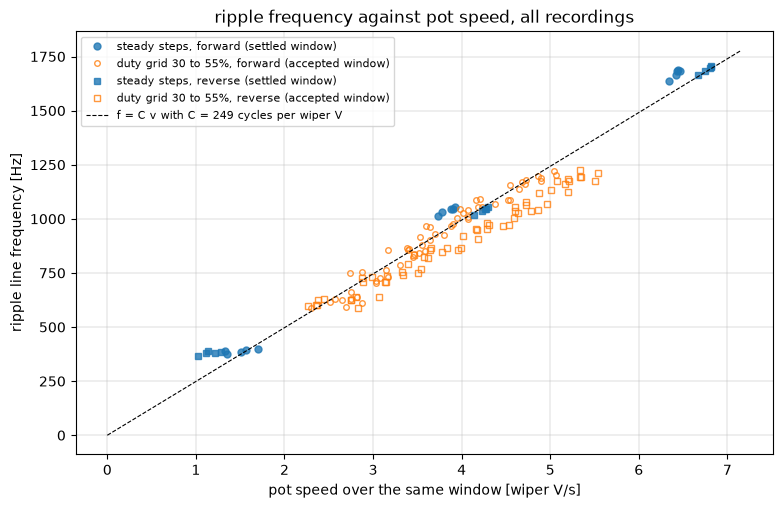

mean    std     min     max  count  travel_V
campaign     mag_pct direction                                                
duty grid    30      forward    243.51   4.45  235.81  250.62      9      0.17
                     reverse    241.88  10.73  227.71  256.83     10     -0.17
             35      forward    260.96   6.15  253.75  269.08      8      0.20
                     reverse    236.55   6.11  225.34  244.79     10     -0.22
             40      forward    263.49  19.41  249.38  317.68     10      0.23
                     reverse    236.99   6.66  227.13  247.35     10     -0.26
             45      forward    255.24   4.99  246.78  263.53     10      0.27
                     reverse    235.74   4.85  230.04  245.32     10     -0.30
             50      forward    268.74  20.17  252.31  302.86     10      0.30
                     reverse    243.50   7.65  231.24  251.57     10     -0.33
             55      forward    251.43   4.85  246.06  260.84     10      0.35
                     reverse    246.44   3.25  239.27  249.14     10     -0.36
steady steps 20      forward    206.48    NaN  206.48  206.48      1      0.15
             40      forward    249.81   0.83  249.01  251.10      5      0.39
                     reverse    242.51   5.49  236.83  248.89      5     -0.41
             60      forward    259.65   2.22  256.82  262.28      5      0.61
                     reverse    243.85   5.57  237.40  250.95      5     -0.65

In [7]:
def ridge_track(x, seed, win=200, hop=20, tol=0.15, fmin=150.0, fmax=F_HI, nfft=8192):
    # Sliding-window peak track, walking backward from the end, seeded with the settled line.
    w = get_window("hann", win)
    f = np.fft.rfftfreq(nfft, DT)
    band = (f >= fmin) & (f <= fmax)
    out = []
    fprev = seed
    for c in np.arange(win // 2, len(x) - win // 2, hop)[::-1]:
        X = np.abs(np.fft.rfft(detrend(x[c - win // 2:c + win // 2]) * w, nfft)) * 2 / w.sum()
        fpk, amp = interp_peak(f, X, max(fmin, fprev * (1 - tol)), min(fmax, fprev * (1 + tol)))
        out.append((c, fpk, amp, np.median(X[band])))
        fprev = fpk
    return pd.DataFrame(out[::-1], columns=["n", "f", "amp", "noise"])

def demod_cycles(x, n_ref, f_ref, lp_frac=0.25):
    # Ripple phase in cycles at every sample: mix down with the ridge phase,
    # low-pass, unwrap the residual, add the ridge phase back.
    n = np.arange(len(x))
    fref = np.interp(n, n_ref, f_ref)
    phref = 2 * np.pi * np.cumsum(fref) * DT
    z = detrend(x) * np.exp(-1j * phref)
    sos = butter(3, max(30.0, lp_frac * fref.min()), "lowpass", fs=TICK_HZ, output="sos")
    zb = sosfiltfilt(sos, z, padlen=min(1000, len(z) - 1))
    return (phref + np.unwrap(np.angle(zb))) / (2 * np.pi)

def motor_angle(seg, c_prior, snr_min=2.0, f_floor=250.0, prior_tol=0.3):
    # Cycles at every sample of a drive step and the first accepted sample.
    x = seg["current_raw"].to_numpy().astype(float) - seg["bias"].iloc[0]
    st = settled(seg)
    v = abs(pot_speed(st))
    f, X = line_spectrum(x[len(seg) - len(st):])
    seed, _ = interp_peak(f, X, max(F_LO, c_prior * v * (1 - prior_tol)), min(F_HI, c_prior * v * (1 + prior_tol)))
    r = ridge_track(x, seed)
    ok = ((r["amp"] / r["noise"] >= snr_min) & (r["f"] >= f_floor)).to_numpy()
    bad = np.where(~ok)[0]
    r = r.iloc[bad.max() + 1:] if len(bad) else r
    cyc = demod_cycles(x, r["n"].to_numpy(), r["f"].to_numpy())
    return cyc, int(r["n"].iloc[0]) + 100, r

# First estimate of the coupling from the settled 20% and 40% lines, which
# are unambiguous (section 5.3), used only to seed the tracker.
C_PRIOR = lines[lines["mag_pct"] <= 40]["cycles_per_V"].median()
MIN_TRAVEL_V = 0.15

def track_step(seg, campaign, name):
    d = np.sign(seg["duty_pct"].iloc[0])
    cyc, n0, r = motor_angle(seg, C_PRIOR)
    if n0 >= len(seg) - 200:
        return None, None
    p = seg["pos"].to_numpy()[n0:] * CH.v_adc_per_count
    th = (cyc[n0:] - cyc[n0]) * d
    if p.max() - p.min() < MIN_TRAVEL_V:
        return None, None
    k = np.polyfit(th, p, 1)
    win = seg.iloc[n0:]
    row = {
        "campaign": campaign, "recording": name, "seg": int(seg["seg"].iloc[0]),
        "mag_pct": int(seg["mag_pct"].iloc[0]),
        "direction": "forward" if d > 0 else "reverse",
        "cycles": th[-1], "travel_V": p[-1] - p[0],
        "cycles_per_V": th[-1] / (p[-1] - p[0]),
        "mV_per_cycle_fit": k[0] * 1e3,
        "residual_rms_mV": (p - np.polyval(k, th)).std() * 1e3,
        "accepted_from_ms": n0 * DT * 1e3,
        "window_line_Hz": r["f"].mean(),
        "window_pot_speed_Vps": abs(pot_speed(win)),
        "p_lo_V": p.min(), "p_hi_V": p.max(),
    }
    trace = pd.DataFrame({"campaign": campaign, "recording": name, "seg": row["seg"],
                          "mag_pct": row["mag_pct"], "direction": row["direction"],
                          "p": p, "theta": th, "res": p - np.polyval(k, th)})
    return row, trace

steps, traces = [], []
for name, (df, meta) in ripple.items():
    for seg_id, seg in df[df["seg"] > 0].groupby("seg"):
        row, trace = track_step(seg, "steady steps", name)
        if row:
            steps.append(row)
            traces.append(trace)
for name, (df, meta) in grid.items():
    for seg_id, seg in df[(df["mag_pct"] >= 30) & (df["mag_pct"] <= 55)].groupby("seg"):
        row, trace = track_step(seg, "duty grid", name)
        if row:
            steps.append(row)
            traces.append(trace)
steps = pd.DataFrame(steps)
traces = pd.concat(traces, ignore_index=True)

C_MEAN = steps["cycles"].abs().sum() / steps["travel_V"].abs().sum()     # travel-weighted, both campaigns
fig, ax = plt.subplots(figsize=(9, 5.5))
for dname, mk in [("forward", "o"), ("reverse", "s")]:
    g = lines[lines["direction"] == dname]
    ax.plot(g["pot_speed_Vps"].abs(), g["f_line_Hz"], mk, ms=5, color="tab:blue", alpha=0.8,
            label=f"steady steps, {dname} (settled window)")
    g = steps[(steps["campaign"] == "duty grid") & (steps["direction"] == dname)]
    ax.plot(g["window_pot_speed_Vps"], g["window_line_Hz"], mk, ms=4, mfc="none", color="tab:orange",
            alpha=0.8, label=f"duty grid 30 to 55%, {dname} (accepted window)")
vv = np.linspace(0, 1.05 * max(lines["pot_speed_Vps"].abs().max(), steps["window_pot_speed_Vps"].max()), 50)
ax.plot(vv, C_MEAN * vv, "k--", lw=0.8, label=f"f = C v with C = {C_MEAN:.0f} cycles per wiper V")
ax.set_xlabel("pot speed over the same window [wiper V/s]")
ax.set_ylabel("ripple line frequency [Hz]")
ax.set_title("ripple frequency against pot speed, all recordings")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
plt.show()

coupling = (steps.groupby(["campaign", "mag_pct", "direction"])["cycles_per_V"]
            .agg(["mean", "std", "min", "max", "count"]))
coupling["travel_V"] = steps.groupby(["campaign", "mag_pct", "direction"])["travel_V"].mean()
coupling.round(2)


In [8]:
def pooled_row(label, g):
    r = g["cycles_per_V"].agg(["mean", "std", "min", "max", "count"])
    r["travel_weighted"] = g["cycles"].abs().sum() / g["travel_V"].abs().sum()
    return {"set": label, **r}

pooled = pd.DataFrame([
    pooled_row("steady steps, all", steps[steps["campaign"] == "steady steps"]),
    pooled_row("steady steps, 40% and 60%", steps[(steps["campaign"] == "steady steps") & (steps["mag_pct"] >= 40)]),
    pooled_row("duty grid 30 to 55%, all", steps[steps["campaign"] == "duty grid"]),
    pooled_row("both campaigns", steps),
    {"set": "settled-window ratio f / v, steady steps", **lines["cycles_per_V"].agg(["mean", "std", "min", "max", "count"]),
     "travel_weighted": np.nan},
]).set_index("set")
pooled["spread_pct"] = (pooled["max"] - pooled["min"]) / pooled["mean"] * 100
pooled["mV_per_cycle"] = 1e3 / pooled["mean"]
pooled["motor_rev_per_wiper_V (from the stated input)"] = pooled["mean"] / PULSES_PER_REV
pooled.round(2)


,mean,std,min,max,count,travel_weighted,spread_pct,mV_per_cycle,motor_rev_per_wiper_V (from the stated input)
set,,,,,,,,,
"steady steps, all",246.93,12.04,206.48,262.28,21.0,248.73,22.60,4.05,41.16
"steady steps, 40% and 60%",248.96,7.88,236.83,262.28,20.0,249.34,10.22,4.02,41.49
"duty grid 30 to 55%, all",248.54,14.38,225.34,317.68,117.0,248.44,37.15,4.02,41.42
both campaigns,248.30,14.02,206.48,317.68,138.0,248.51,44.78,4.03,41.38
"settled-window ratio f / v, steady steps",269.79,31.70,235.49,355.61,30.0,NaN,44.52,3.71,44.97


### 5.3 Amplitude, harmonics and the line family


In [9]:
cols = ["mean_current_A", "amp_mA", "ratio_2f", "ratio_f/2", "ratio_f/3", "ratio_f/6",
        "terminal_ripple_mV", "brake_window_ripple_counts"]
tab = lines.groupby("mag_pct")[cols].agg(["mean", "min", "max"]).round(3)
tab[("amp_over_mean_current_pct", "mean")] = (lines["amp_mA"] / (lines["mean_current_A"] * 1e3)).groupby(lines["mag_pct"]).mean().round(3) * 100
tab[("terminal_ripple_per_current_ohm", "mean")] = (lines["terminal_ripple_mV"] / lines["amp_mA"]).groupby(lines["mag_pct"]).mean().round(3)
tab


mean_current_A               amp_mA               ratio_2f               ratio_f/2               ratio_f/3               ratio_f/6               terminal_ripple_mV                 \
                  mean    min    max   mean    min    max     mean    min    max      mean    min    max      mean    min    max      mean    min    max               mean    min     max   
mag_pct                                                                                                                                                                                      
20               0.043  0.042  0.045  6.219  5.777  6.811    0.264  0.214  0.293     0.344  0.253  0.431     0.224  0.158  0.335     0.432  0.322  0.636              6.937  6.056   7.948   
40               0.068  0.066  0.069  8.229  7.797  9.206    0.117  0.082  0.155     0.283  0.111  0.493     0.207  0.145  0.249     0.420  0.253  0.721             10.222  9.399  12.048   
60               0.088  0.085  0.090  7.592  6.935  8.584    0.109  0.077  0.147     0.327  0.146  0.509     0.218  0.129  0.334     0.548  0.314  0.728              7.581  5.857   9.306   

        brake_window_ripple_counts               amp_over_mean_current_pct terminal_ripple_per_current_ohm  
                              mean    min    max                      mean                            mean  
mag_pct                                                                                                     
20                           0.203  0.097  0.336                      14.5                           1.114  
40                           0.250  0.177  0.305                      12.2                           1.242  
60                           0.823  0.731  0.955                       8.7                           0.996

Findings for section 5:

- **The line.** Every settled step shows one dominant line, at 388 Hz
  forward and 380 Hz reverse for 20% duty (364 to 400 Hz over ten steps),
  1038 and 1039 Hz at 40%, and 1671 and 1690 Hz at 60%. Those are about
  half the 834, 1920 and 2980 Hz of the retired battery run, which is the
  supply. The line stands 32 to 38 times above the median spectrum at 20%
  and 40% and 22 to 27 times at 60%, where the noise floor rises with the
  current. No step in this session needed the family rule of section 5.1.
  The largest sub-line reaches 0.73 of the line and the largest peak in
  the band was the ripple line every time.
- **The bus line.** The board's telemetry coupling shows up where section
  1 said it would. The bridge-off baseline carries a line at 1250 Hz of
  0.32 counts against a median spectrum of 0.02, so it is the largest
  thing in an idle current spectrum. Inside a drive step the three bus
  lines run 0.44 to 0.60 counts on average and 1.15 counts at worst, and
  the ripple line is 11 to 15 times taller by duty and never under 7 times
  in any single step. So the artifact is real, it is measurable, and it
  does not reach the tachometer. Nothing is filtered.
- **Width.** The full width at half amplitude is 32 to 36 Hz at 20% (8.4%
  to 9.3% of the line), 60 to 64 Hz at 40% (5.8% to 6.2%), and 107 to
  119 Hz at 60% (6.4% to 7.0%), against 24 Hz for a pure tone through the
  same window. At 20% the line is only about 1.5 times wider than the
  resolution floor, so that row is mostly the window and not the motor.
  *Hypothesis (not tested here): the excess width is the chirp of a speed
  still rising in the settled window, which starts 48 ms into the step,
  under three of the 17 to 21 ms mechanical time constants of notebook 04,
  so a speed rise of a few percent inside the window is expected and a few
  percent of the line is the order of the widths measured.*
- **Frequency against speed.** The line frequency is proportional to the
  pot speed with a slope of 270 cycles per wiper volt over the thirty
  settled windows, but the scatter is 235 to 356, a 45% spread against the
  20% the battery run showed. Both things that got worse are on the pot
  side. The windows are half as long in travel at half the speed, and the
  position channel is dropping codes (section 4.1). The demodulated
  coupling below does not use this ratio and does not carry that scatter.
- **The coupling, and it agrees with the retired run.** Counted as
  demodulated cycles per volt of travel, the 40% and 60% steady steps give
  249 cycles per wiper volt, the duty grid gives 248, and both campaigns
  together give 248.5 travel-weighted, 4.02 mV of wiper per cycle. The
  retired battery run on chain 2 gave 247.6 and 4.04 mV. That is agreement
  to 0.4% across a chain rebuild and a supply change, which is what a
  mechanical constant should do. With the stated six pulses per revolution
  it is 41.4 motor revolutions per wiper volt against 41.3. This is the
  one number in this notebook I would carry forward.
- **The per-step spread got worse.** The pooled spread over both campaigns
  is 45% where it was 18%, and the outliers are all forward grid steps at
  40% and 50% duty reading 300 to 318 cycles per wiper volt. Those steps
  travel 0.23 to 0.30 V on USB where they travelled about twice that on
  the battery, so a few counts of position error at either end of a short
  travel moves the ratio a long way, and section 4.1 says the position
  channel has more than a few counts of error. The travel-weighted number
  is barely moved by them, since it weights each step by its travel.
- **Only one 20% steady step survives the tracker.** At 20% duty on USB
  the part of a 120 ms step the tracker accepts covers about 0.15 V, right
  at the minimum travel the tracker demands, and nine of the ten 20% steady
  steps fall below it. The
  one that got through reads 206 cycles per wiper volt over 0.15 V of
  travel, which is the short-travel scatter of the point above and not a
  measurement I would quote on its own.
- **Amplitude.** The line amplitude is 6.2 mA at 20%, 8.2 mA at 40% and
  7.6 mA at 60%, which is 14.5%, 12.2% and 8.7% of the mean drive current.
  The retired run read 9.1, 8.5 and 6.8 mA. The same ripple appears on the
  terminal difference at 6.9, 10.2 and 7.6 mV, which is 1.0 to 1.2 Ohm per
  ampere of ripple across the three duties, where the retired run read
  0.88 Ohm falling to 0.57. The chain change accounts for 0.027 Ohm of
  that through the shunt and nothing else I can name, and the retired run's
  20% point was below its own voltage floor so its terminal sample was not
  settled. I leave the difference open. *Hypothesis (not tested here): the
  terminal ripple is the current ripple across the on-resistance of the
  bridge and the shunt, 0.3 Ohm on the low side alone by notebook 01,
  which does not cover 1 Ohm, so something else in the terminal path is
  carrying it.* The brake-window shunt sample carries 0.2 to 0.8 counts at
  the line against 6.9 to 9.2 counts on the crest-scan sample, an order of
  magnitude down. The ripple is a drive-window feature and the trough scan
  cannot serve as a tachometer.
- **Harmonics and sub-lines.** The second harmonic is 0.11 to 0.26 of the
  line. Below the line there is the same family of sub-lines at one half,
  one third and one sixth of its frequency, at 0.28 to 0.34, 0.21 to 0.22
  and 0.42 to 0.55 of the line. Unlike the battery run they do not grow
  with duty here. At 20% duty the one-sixth sub-line sits at 65 Hz, under
  five cycles inside the 72 ms window, so that entry is not worth much.
  With six pulses per revolution these are the first, second and third
  harmonics of a once-per-revolution modulation. *Hypothesis (not tested
  here): the modulation is a brush or commutator asymmetry that makes the
  six commutation steps of a revolution unequal. The data cannot tell a
  single pulse per line cycle from a close pair, so the conversion to
  revolutions rests entirely on the stated input.*


## 6. Pot linearity

### 6.1 Motor-side angle against the pot inside a step

The demodulated ripple phase of section 5.2 is a motor-side angle in
cycles at every sample. Within one step the pot position is plotted
against it and a line is fitted. The residual of the pot from that line is
the pot's departure from proportionality to the motor angle, in wiper
volts, as a function of position. The left panel shows one 60% step, with
the motor angle and the pot against time. The right panel overlays the
residual of every accepted 40% step of the steady-step campaign against
absolute position, forward and reverse. Every trace has its own fitted
line, so the offsets between traces carry no information and the shapes
do.


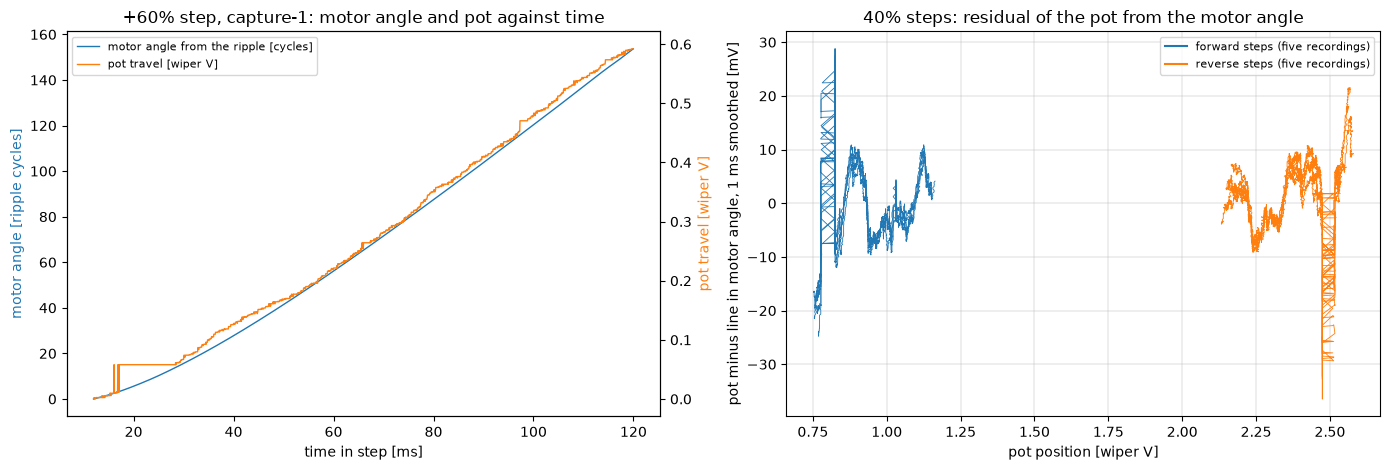

cycles_per_V                 residual_rms_mV               travel_V             accepted_from_ms            
                          mean     min     max            mean    min    max     mean   min   max             mean   min   max
mag_pct direction                                                                                                             
20      forward         206.48  206.48  206.48           12.42  12.42  12.42     0.15  0.15  0.15             35.0  35.0  35.0
40      forward         249.81  249.01  251.10            9.46   9.23   9.74     0.39  0.38  0.40             12.2  10.0  16.0
        reverse         242.51  236.83  248.89            9.04   8.57   9.53    -0.41 -0.42 -0.40             12.0  10.0  15.0
60      forward         259.65  256.82  262.28            8.59   8.42   8.80     0.61  0.59  0.62             10.4  10.0  12.0
        reverse         243.85  237.40  250.95            8.38   7.36   9.23    -0.65 -0.67 -0.64             11.0  10.0  13.0

In [10]:
name, (df, meta) = next(iter(ripple.items()))
seg = df[df["seg"] == 3]
cyc, n0, r = motor_angle(seg, C_PRIOR)
t = np.arange(len(seg)) * DT * 1e3
p = seg["pos"].to_numpy() * CH.v_adc_per_count

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
ax = axes[0]
ax.plot(t[n0:], cyc[n0:] - cyc[n0], color="tab:blue", lw=1, label="motor angle from the ripple [cycles]")
ax.set_xlabel("time in step [ms]")
ax.set_ylabel("motor angle [ripple cycles]", color="tab:blue")
ax2 = ax.twinx()
ax2.plot(t[n0:], p[n0:] - p[n0], color="tab:orange", lw=1, label="pot travel [wiper V]")
ax2.set_ylabel("pot travel [wiper V]", color="tab:orange")
ax.set_title(f"+60% step, {name}: motor angle and pot against time")
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=8)
ax = axes[1]
for (rec, sid), g in traces[(traces["campaign"] == "steady steps") & (traces["mag_pct"] == 40)].groupby(["recording", "seg"]):
    rs = np.convolve(g["res"].to_numpy(), np.ones(20) / 20, mode="same")
    ax.plot(g["p"].to_numpy()[10:-10], rs[10:-10] * 1e3, lw=0.6,
            color="tab:blue" if g["direction"].iloc[0] == "forward" else "tab:orange")
ax.plot([], [], color="tab:blue", label="forward steps (five recordings)")
ax.plot([], [], color="tab:orange", label="reverse steps (five recordings)")
ax.set_xlabel("pot position [wiper V]")
ax.set_ylabel("pot minus line in motor angle, 1 ms smoothed [mV]")
ax.set_title("40% steps: residual of the pot from the motor angle")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
plt.tight_layout()
plt.show()

cols = ["cycles_per_V", "residual_rms_mV", "travel_V", "accepted_from_ms"]
steps[steps["campaign"] == "steady steps"].groupby(["mag_pct", "direction"])[cols].agg(["mean", "min", "max"]).round(2)


### 6.2 Wiper volts per ripple cycle against position

The local gain of the pot is the slope of position against motor angle
within a bin of position. It is fitted in consecutive windows of five
cycles (about 20 mV) on every accepted trace of both campaigns, each
window placed at its mean position, and pooled in 20 mV bins of position,
which needs no alignment between traces since a slope has no offset.
Windows are cut on the motor angle, the independent variable of the fit,
so the pooled slope is unbiased. The figure shows the pooled
local gain against position with the spread across traces, and the table
reduces it to 0.25 V bands. Two more figures of merit follow. The
reproducibility of the pattern is the rms difference between the residual
traces of different recordings at the same positions, taken within each
group of steps that covers the same range. The lower panel integrates the
pooled gain into the pot's departure from proportionality over the whole
covered range, one curve free of per-trace offsets, and the quasi-period
of the pattern is the spacing of its successive maxima. The summary ends
with the extreme local gains and their positions in the min column, then
the positions of the two sticky codes of section 4.1 for comparison.


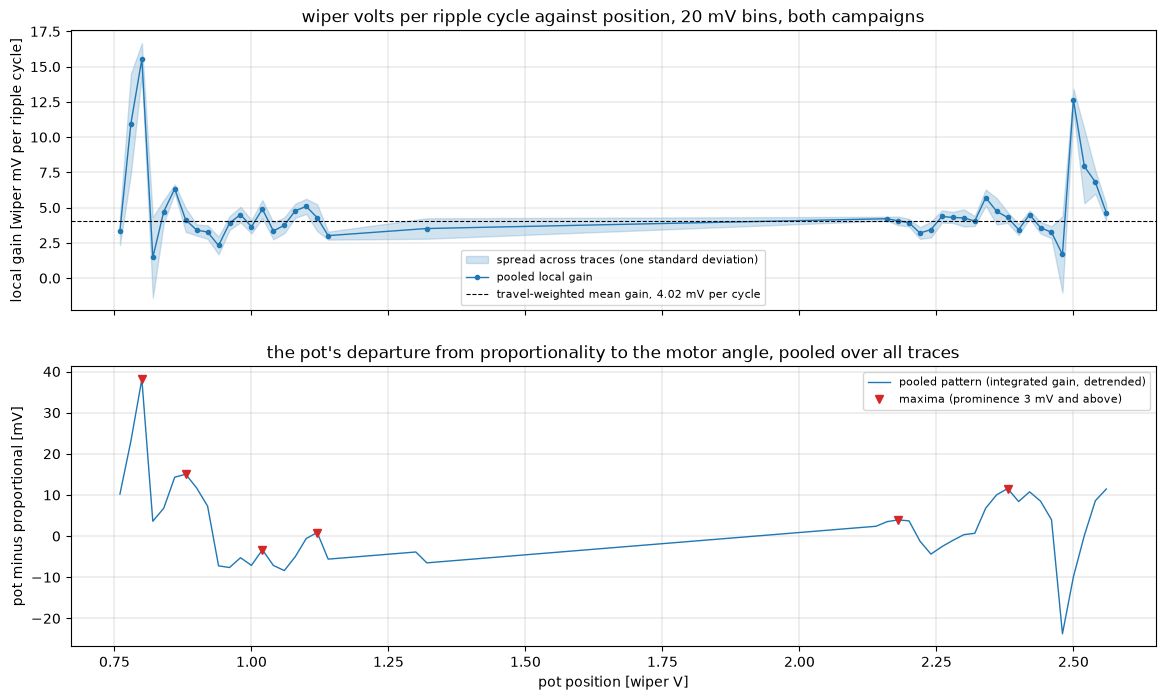

,mV_per_cycle,cycles_per_V,gain_min,gain_min_at_V,gain_max,gain_max_at_V,within_band_swing_pct,traces_per_bin
band_V,,,,,,,,
0.75,3.79,263.52,1.47,0.82,15.54,0.80,264.00,61.17
1.00,4.03,247.94,3.02,1.14,5.09,1.10,50.56,24.00
1.25,3.52,284.00,3.52,1.32,3.52,1.32,0.00,8.00
2.00,3.57,279.80,3.20,2.22,4.21,2.16,26.90,22.40
2.25,3.66,273.18,1.68,2.48,5.71,2.34,100.42,61.75
2.50,9.01,111.05,4.64,2.56,12.64,2.50,99.92,20.75


In [11]:
BIN_V = 0.02
WIN_CYCLES = 5

def local_gains(trace):
    # Slope of position against motor angle in consecutive windows of five
    # cycles (about 20 mV), each placed at its mean position. Windows are cut
    # on the motor angle, the independent variable, so the slope is unbiased.
    p, th = trace["p"].to_numpy(), trace["theta"].to_numpy()
    out = []
    for a in np.arange(th.min(), th.max() - WIN_CYCLES, WIN_CYCLES):
        m = (th >= a) & (th < a + WIN_CYCLES)
        if m.sum() >= 20:
            out.append({"bin_V": np.round(p[m].mean() / BIN_V) * BIN_V,
                        "mV_per_cycle": np.polyfit(th[m], p[m], 1)[0] * 1e3})
    return pd.DataFrame(out)

gains = []
for (camp, rec, sid), g in traces.groupby(["campaign", "recording", "seg"]):
    lg = local_gains(g)
    lg["campaign"], lg["recording"], lg["seg"], lg["direction"] = camp, rec, sid, g["direction"].iloc[0]
    gains.append(lg)
gains = pd.concat(gains, ignore_index=True)
gmap = gains.groupby("bin_V")["mV_per_cycle"].agg(["mean", "std", "count"]).reset_index()
gmap = gmap[gmap["count"] >= 8].sort_values("bin_V").reset_index(drop=True)
G_MEAN = 1e3 / C_MEAN

# Pooled pattern: the residual of the pot from proportionality, integrated
# from the pooled gain over a contiguous 20 mV grid (missing bins take the
# mean gain), then detrended.
gridp = np.arange(gmap["bin_V"].min(), gmap["bin_V"].max() + BIN_V / 2, BIN_V)
gain_on_grid = np.interp(gridp, gmap["bin_V"], gmap["mean"])
gain_on_grid[np.abs(gridp[:, None] - gmap["bin_V"].to_numpy()[None, :]).min(axis=1) > BIN_V / 2] = G_MEAN
pattern = np.cumsum((1 - G_MEAN / gain_on_grid) * BIN_V)
pattern -= np.polyval(np.polyfit(gridp, pattern, 1), gridp)
pk_idx, _ = find_peaks(pattern, prominence=0.003)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
ax = axes[0]
ax.fill_between(gmap["bin_V"], gmap["mean"] - gmap["std"], gmap["mean"] + gmap["std"], color="tab:blue", alpha=0.2,
                label="spread across traces (one standard deviation)")
ax.plot(gmap["bin_V"], gmap["mean"], "-o", ms=3, lw=1, color="tab:blue", label="pooled local gain")
ax.axhline(G_MEAN, color="k", lw=0.8, ls="--", label=f"travel-weighted mean gain, {G_MEAN:.2f} mV per cycle")
ax.set_ylabel("local gain [wiper mV per ripple cycle]")
ax.set_title("wiper volts per ripple cycle against position, 20 mV bins, both campaigns")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
ax = axes[1]
ax.plot(gridp, pattern * 1e3, "-", lw=1, color="tab:blue", label="pooled pattern (integrated gain, detrended)")
ax.plot(gridp[pk_idx], pattern[pk_idx] * 1e3, "v", color="tab:red", ms=6, label="maxima (prominence 3 mV and above)")
ax.set_xlabel("pot position [wiper V]")
ax.set_ylabel("pot minus proportional [mV]")
ax.set_title("the pot's departure from proportionality to the motor angle, pooled over all traces")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
plt.show()

gmap["band_V"] = (gmap["bin_V"] // 0.25) * 0.25
bands = gmap.groupby("band_V").apply(lambda g: pd.Series({
    "mV_per_cycle": np.average(g["mean"], weights=g["count"]),
    "cycles_per_V": 1e3 / np.average(g["mean"], weights=g["count"]),
    "gain_min": g["mean"].min(), "gain_min_at_V": g.loc[g["mean"].idxmin(), "bin_V"],
    "gain_max": g["mean"].max(), "gain_max_at_V": g.loc[g["mean"].idxmax(), "bin_V"],
    "within_band_swing_pct": (g["mean"].max() - g["mean"].min()) / g["mean"].mean() * 100,
    "traces_per_bin": g["count"].mean(),
}), include_groups=False)
bands.round(2)


In [12]:
# Reproducibility: rms difference between residual traces of different
# recordings within a group that covers the same range, on a 2 mV grid.
def group_repro(g):
    lo = g.groupby(["recording", "seg"])["p"].min().max() + 0.01
    hi = g.groupby(["recording", "seg"])["p"].max().min() - 0.01
    if hi - lo < 0.1:
        return None
    gridp = np.arange(lo, hi, 0.002)
    curves = []
    for (rec, sid), t in g.groupby(["recording", "seg"]):
        order = np.argsort(t["p"].to_numpy())
        c = np.interp(gridp, t["p"].to_numpy()[order], t["res"].to_numpy()[order])
        curves.append(c - np.polyval(np.polyfit(gridp, c, 1), gridp))
    curves = np.array(curves)
    mean = curves.mean(axis=0)
    return {"traces": len(curves), "range_V": hi - lo,
            "pattern_rms_mV": mean.std() * 1e3,
            "pattern_pk_pk_mV": (mean.max() - mean.min()) * 1e3,
            "between_trace_rms_mV": (curves - mean).std() * 1e3}

rows = []
for (camp, mag, dname), g in traces.groupby(["campaign", "mag_pct", "direction"]):
    r = group_repro(g)
    if r:
        rows.append({"campaign": camp, "mag_pct": mag, "direction": dname, **r})
repro = pd.DataFrame(rows).set_index(["campaign", "mag_pct", "direction"])

# Quasi-period of the pooled pattern: spacing of its successive maxima.
spacing = np.diff(gridp[pk_idx])
summary = repro.agg(["mean", "min", "max"]).T
summary.loc["pooled_pattern_maxima_spacing_V"] = [spacing.mean(), spacing.min(), spacing.max()]
summary.loc["pooled_pattern_maxima_count"] = [len(pk_idx), np.nan, np.nan]
summary.loc["pooled_pattern_rms_mV"] = [pattern.std() * 1e3, np.nan, np.nan]
summary.loc["pooled_pattern_pk_pk_mV"] = [(pattern.max() - pattern.min()) * 1e3, np.nan, np.nan]
summary.loc["pooled_gain_min_mV_per_cycle"] = [gmap["mean"].min(), gmap.loc[gmap["mean"].idxmin(), "bin_V"], np.nan]
summary.loc["pooled_gain_max_mV_per_cycle"] = [gmap["mean"].max(), gmap.loc[gmap["mean"].idxmax(), "bin_V"], np.nan]
# where the two sticky codes of section 4.1 sit, for comparison with the two rows above
for c in POT_STICKY:
    summary.loc[f"sticky code {c} at [wiper V]"] = [c * CH.v_adc_per_count, np.nan, np.nan]
summary.round(3)


,mean,min,max
traces,8.118,1.000,10.000
range_V,0.258,0.110,0.591
pattern_rms_mV,4.848,3.573,5.894
pattern_pk_pk_mV,20.550,16.016,29.641
between_trace_rms_mV,1.421,0.000,2.291
pooled_pattern_maxima_spacing_V,0.316,0.080,1.060
pooled_pattern_maxima_count,6.000,NaN,NaN
pooled_pattern_rms_mV,7.619,NaN,NaN
pooled_pattern_pk_pk_mV,61.868,NaN,NaN
pooled_gain_min_mV_per_cycle,1.470,0.820,NaN


Findings for section 6:

- **The position channel spoils this section, and here is how it shows.**
  The pooled local gain runs from 1.47 mV per cycle at 0.82 V to 15.54 mV
  per cycle at 0.80 V, around a travel-weighted mean of 4.02. Those two
  bins are next to each other, and 1024 counts, the code the converter
  sticks on, is 0.825 V. The other extreme in the table is the 2.50 V
  band, which averages 9.01 mV per cycle with a maximum of 12.64, and the
  second sticky code, 3071, is 2.474 V. Both ends of the map sit on top of
  a sticky code. What the map is reading there is the pot standing still
  in the data while the motor turns, which is the converter and not the
  gear train.
- **Reproducibility no longer decides anything.** The traces of a group
  overlay each other to 1.42 mV rms at the same positions, as good as the
  battery run's 1.75 mV, and the pattern is 20.6 mV peak to peak within a
  group and 61.9 mV pooled. On the battery run that repeatability was the
  argument that the pattern is a fixed function of output position and
  therefore mechanical. It is not an argument any more. A converter that
  drops the same codes every time also produces a pattern that is a fixed
  function of position and repeats perfectly from recording to recording.
  The test that separated the two on chain 2 does not separate them here.
- **The coverage broke up as well.** The map holds bins from 0.76 to
  1.14 V, one lone bin at 1.32 V, and then nothing until 2.16 V, because
  an 80 ms grid step on USB covers about 0.17 to 0.36 V instead of 0.30 to
  0.56, and the 40% and 60% steady steps cover 0.39 to 0.65 V instead of
  0.72 to 1.10. The 1.25 V band of the table rests on that one bin alone.
  The pooled pattern spans a 0.84 V gap that is filled with the mean gain,
  so its six maxima and their 0.32 V average spacing are not comparable
  with the eleven maxima at 0.17 V spacing the battery run found.
- **What I can and cannot say.** The residual of the pot from the motor
  angle inside a step is 8.4 to 9.5 mV rms by group against a position
  noise of 1.3 to 1.6 mV, so the pot and the motor angle do disagree by
  much more than the pot's noise. That much survives. Which part of the
  disagreement is the gear train, which part is the pot track and which
  part is the converter, this dataset cannot say, and the battery run's
  answer (a 46 mV peak to peak pattern with a 0.17 V quasi-period, a local
  gain swinging between 1.9 and 7.2 mV per cycle) is neither confirmed nor
  contradicted here. Redoing section 6 needs a board whose position
  channel does not drop codes. I am not going to patch around the missing
  codes to produce a map, because the information the map wants is the
  thing the converter threw away.
- **The 13% band-to-band figure is gone too.** Averaged over 0.25 V bands
  the gain reads 3.52 to 4.03 mV per cycle over 0.75 to 2.25 V, which
  would look like the battery run's 3.6 to 4.1, but the 2.50 band reads
  9.01 and the bands themselves rest on the contaminated bins. I would not
  quote a position dependence of the coupling from this session.


## 7. Gear play

### 7.1 One reversal

At a flip the drive current jumps to several times its steady value and
then decays as the motor decelerates, reverses and speeds up in the new
direction, and the commutation steps ride on it. Near zero speed the steps
are milliseconds apart and each is a one-sample jump of tens of counts, so
the spectral tracker of section 5.2 gives way to a step detector. A
commutation step is a one-sample change of the current that exceeds 10% of
the local current (21-sample median) and at least 10 counts, with jumps
within four samples of each other merged into one. The sensitivity of every
count to that threshold is reported alongside it, at 8% and 12%.

The 10-count floor is the same number the retired run used. It is in ADC
counts and not in milliamperes on purpose. The floor is there to keep the
channel's own noise out, and that noise is about 2 counts rms on both
chains (notebook 00, section 5.2), so 10 counts is five times the noise
either way. In current units it is 9.0 mA on chain 3 where it was 16.3 mA
on chain 2, so the detector is more sensitive than it was, which matters
because the currents at a flip are smaller on USB. The fractional part of
the threshold does most of the work at these current levels anyway.

Three instants are read from each flip. The pot's stop $t_{stop}$ and
resumption $t_{res}$ bound the plateau of the position, smoothed over
1 ms, within two counts (1.6 mV) of its extreme value. The motor's zero
crossing $t_m$ is the midpoint of the widest interval between consecutive
commutation steps within 3 to 30 ms after the flip, where the step rate
passes through zero. The dwell is $t_{res} - t_{stop}$. The dwell travel
is the number of commutation steps within the dwell divided by the coupling
$C$ of section 5.2, the wiper-equivalent travel of the motor while the pot
stands still, and is this notebook's measure of the gear play. The
overshoot is the pot's travel in the old direction after the flip, the
braking distance. The figure follows one 40% flip.

The plateau test asks whether the position reading stops changing, and
section 4.1 says this board's position reading has two codes it stops
changing on by itself. So every flip also reports what share of its
plateau sits on one of those two codes. That column is the honest measure
of how much of the dwell below is the mechanism and how much is the
converter.


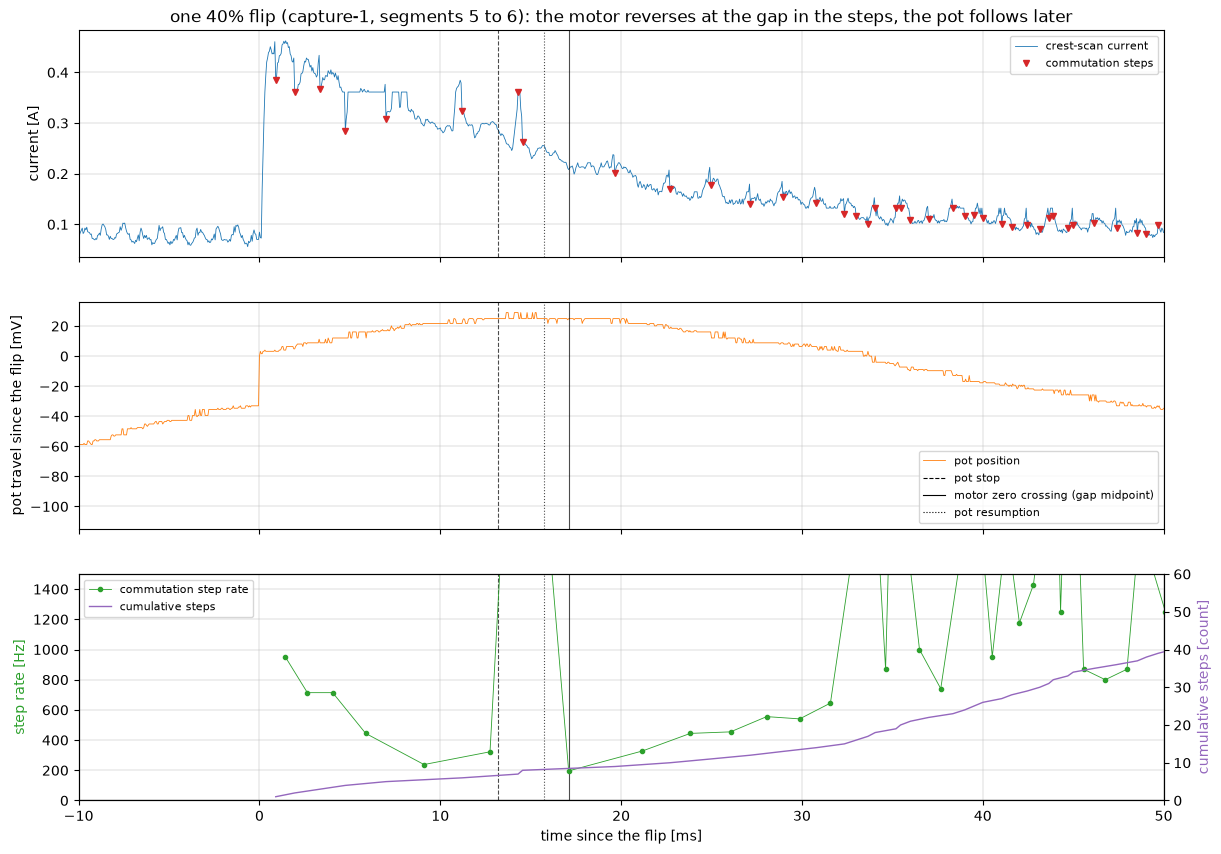

,value
mag_pct,40
old_direction,forward
f_pre_Hz,925.168656
v_pre_Vps,3.747899
peak_current_A,0.425679
overshoot_mV,59.820557
t_stop_ms,13.2
t_res_ms,15.75
steps_in_dwell_8pct,2
steps_in_dwell,2


In [13]:
def step_events(x, frac=0.10, floor=10, dist=4):
    # Commutation steps: one-sample jumps above a threshold scaled to the local current.
    d1 = np.zeros_like(x)
    d1[1:] = np.diff(x)
    thr = np.maximum(floor, frac * np.abs(medfilt(x, 21)))
    ev = []
    for k in np.where(np.abs(d1) >= thr)[0]:
        if ev and k - ev[-1][0] <= dist:
            if abs(d1[k]) > abs(ev[-1][1]):
                ev[-1] = (k, d1[k])
        else:
            ev.append((k, d1[k]))
    return np.array([e[0] for e in ev], dtype=int)

PLATEAU_COUNTS = 2
EDGE = 10          # samples excluded at both ends of the post-flip segment (inductive rise, segment end)

def analyze_flip(pre, post, C):
    old = np.sign(pre["duty_pct"].iloc[0])
    x = post["current_raw"].to_numpy().astype(float) - post["bias"].iloc[0]
    p = post["pos"].to_numpy().astype(float) * old              # old direction positive
    p0 = np.median(pre["pos"].to_numpy()[-10:]) * old
    ps = np.convolve(p, np.ones(20) / 20, mode="same")
    top = ps[EDGE:-EDGE].max()
    within = np.where(np.abs(ps - top) <= PLATEAU_COUNTS)[0]
    within = within[(within >= EDGE) & (within < len(p) - EDGE)]
    k_stop, k_res = within.min(), within.max()
    f, X = line_spectrum(pre["current_raw"].to_numpy()[-400:].astype(float))
    f_pre, _ = settled_line(f, X)
    out = {
        "mag_pct": int(post["mag_pct"].iloc[0]),
        "old_direction": "forward" if old > 0 else "reverse",
        "f_pre_Hz": f_pre,
        "v_pre_Vps": pot_speed(pre.iloc[-400:]) * old,
        "peak_current_A": np.median(x[EDGE:60]) * CH.a_per_count,
        "overshoot_mV": (top - p0) * CH.v_adc_per_count * 1e3,
        "t_stop_ms": k_stop * DT * 1e3,
        "t_res_ms": k_res * DT * 1e3,
    }
    for frac, tag in [(0.08, "steps_in_dwell_8pct"), (0.10, "steps_in_dwell"), (0.12, "steps_in_dwell_12pct")]:
        ev = step_events(x, frac=frac)
        ev = ev[(ev >= EDGE) & (ev < len(x) - EDGE)]
        out[tag] = int(np.sum((ev > k_stop) & (ev < k_res)))
        if frac == 0.10:
            te = ev * DT * 1e3
            mid, gap = (te[1:] + te[:-1]) / 2, np.diff(te)
            m = (mid > 3) & (mid < 30)
            g = np.argmax(gap[m])
            out["t_m_ms"] = mid[m][g]
            out["gap_ms"] = gap[m][g]
            near = (te > out["t_res_ms"] - 3) & (te < out["t_res_ms"] + 3)
            out["motor_rate_at_res_Hz"] = near.sum() / 6e-3
            events = ev
    out["dwell_ms"] = out["t_res_ms"] - out["t_stop_ms"]
    out["dwell_travel_mV"] = out["steps_in_dwell"] / C * 1e3
    out["t_stop_minus_t_m_ms"] = out["t_stop_ms"] - out["t_m_ms"]
    # How much of the plateau is the position ADC sitting on a sticky code
    # rather than the mechanism standing still (section 4.1).
    plate = post["pos"].to_numpy()[k_stop:k_res + 1]
    out["dwell_on_sticky_pct"] = float(np.isin(plate, POT_STICKY).mean()) * 100 if len(plate) else 0.0
    return out, events

C_STEADY = C_MEAN
flips = []
for name, (df, meta) in reversal.items():
    for a, b in flip_pairs(meta):
        row, _ = analyze_flip(df[df["seg"] == a], df[df["seg"] == b], C_STEADY)
        row.update({"recording": name, "flip": f"{a}->{b}"})
        flips.append(row)
flips = pd.DataFrame(flips)

name, (df, meta) = next(iter(reversal.items()))
a, b = flip_pairs(meta)[2]
pre, post = df[df["seg"] == a], df[df["seg"] == b]
row, events = analyze_flip(pre, post, C_STEADY)
both = pd.concat([pre.iloc[-400:], post])
n_pre = 400
x = both["current_raw"].to_numpy().astype(float) - both["bias"].iloc[0]
p = both["pos"].to_numpy() * CH.v_adc_per_count * 1e3
t = (np.arange(len(both)) - n_pre) * DT * 1e3
te = events * DT * 1e3
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
axes[0].plot(t, x * CH.a_per_count, lw=0.6, color="tab:blue", label="crest-scan current")
axes[0].plot(te, x[events + n_pre] * CH.a_per_count, "v", ms=4, color="tab:red", label="commutation steps")
axes[0].set_ylabel("current [A]")
axes[0].legend(fontsize=8, loc="upper right")
axes[1].plot(t, p - p[n_pre], lw=0.6, color="tab:orange", label="pot position")
for key, ls, lab in [("t_stop_ms", "--", "pot stop"), ("t_m_ms", "-", "motor zero crossing (gap midpoint)"), ("t_res_ms", ":", "pot resumption")]:
    for ax in axes:
        ax.axvline(row[key], color="k", lw=0.8, ls=ls, alpha=0.7)
    axes[1].plot([], [], "k", ls=ls, lw=0.8, label=lab)
axes[1].set_ylabel("pot travel since the flip [mV]")
axes[1].legend(fontsize=8, loc="lower right")
mid = (te[1:] + te[:-1]) / 2
axes[2].plot(mid, 1e3 / np.diff(te), "o-", ms=3, lw=0.6, color="tab:green", label="commutation step rate")
axes[2].set_ylabel("step rate [Hz]", color="tab:green")
axes[2].set_xlabel("time since the flip [ms]")
axes[2].set_ylim(0, 1500)
ax2 = axes[2].twinx()
ax2.plot(te, np.arange(1, len(te) + 1), "-", lw=1, color="tab:purple", label="cumulative steps")
ax2.set_ylabel("cumulative steps [count]", color="tab:purple")
ax2.set_ylim(0, 60)
h1, l1 = axes[2].get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
axes[2].legend(h1 + h2, l1 + l2, fontsize=8, loc="upper left")
axes[2].set_xlim(-10, 50)
for ax in axes:
    ax.grid(True, lw=0.3)
axes[0].set_title(f"one 40% flip ({name}, segments {a} to {b}): the motor reverses at the gap in the steps, the pot follows later")
plt.show()

pd.DataFrame([row]).T.rename(columns={0: "value"}).round(2)


### 7.2 Play per direction and amplitude

The table pools the ten flips of each direction and amplitude over the five
recordings. Direction is the direction of the drive before the flip.


In [14]:
cols = ["f_pre_Hz", "v_pre_Vps", "peak_current_A", "overshoot_mV", "t_stop_ms", "t_m_ms", "gap_ms",
        "t_stop_minus_t_m_ms", "t_res_ms", "dwell_ms", "steps_in_dwell", "dwell_travel_mV",
        "motor_rate_at_res_Hz", "dwell_on_sticky_pct"]
play = flips.groupby(["mag_pct", "old_direction"])[cols].agg(["mean", "std", "min", "max"]).round(2)
play.T


mag_pct                        20               40         
old_direction             forward reverse  forward  reverse
f_pre_Hz             mean  355.34  354.77   895.36   902.85
                     std    15.12    7.76    41.49    37.71
                     min   331.88  343.71   849.20   849.51
                     max   374.44  368.39   943.68   947.81
v_pre_Vps            mean    1.91    2.19     3.73     3.60
                     std     1.88    2.10     0.57     0.61
                     min    -0.00    0.00     2.95     2.20
                     max     4.48    4.94     4.71     4.28
peak_current_A       mean    0.14    0.14     0.43     0.43
                     std     0.01    0.00     0.01     0.01
                     min     0.13    0.14     0.42     0.41
                     max     0.15    0.15     0.44     0.44
overshoot_mV         mean   13.49   23.80    30.90    48.56
                     std    10.61   25.45    12.00    23.03
                     min     0.00    0.00    16.92     6.45
                     max    27.63   61.11    59.82    69.57
t_stop_ms            mean    5.71    4.68     7.63     8.73
                     std     2.96    1.97     3.34     4.43
                     min     0.50    0.50     2.45     0.50
                     max     8.55    6.75    13.20    12.60
t_m_ms               mean   14.41   16.14    14.28    12.03
                     std     5.50    6.48     2.58     3.04
                     min     7.52    9.98    12.08     4.40
                     max    25.08   29.30    18.77    16.88
gap_ms               mean    8.32   10.06     7.68     6.00
                     std     2.10    2.60     1.85     1.21
                     min     5.35    7.50     5.10     4.55
                     max    11.50   16.30     9.95     8.45
t_stop_minus_t_m_ms  mean   -8.70  -11.46    -6.65    -3.30
                     std     6.77    7.65     2.66     5.46
                     min   -18.48  -26.30   -11.12   -11.60
                     max    -2.15   -3.62    -2.52     6.65
t_res_ms             mean   25.15   25.89    22.47    22.65
                     std    13.22    6.67     4.85     7.47
                     min    13.45   19.55    15.75    16.45
                     max    49.15   41.55    31.90    38.50
dwell_ms             mean   19.44   21.22    14.84    13.92
                     std    15.95    8.25     7.92    11.78
                     min     6.95   14.15     2.55     4.70
                     max    48.65   41.05    29.45    38.00
steps_in_dwell       mean    5.60    5.60     4.90     5.50
                     std     5.82    2.88     4.12     8.50
                     min     0.00    2.00     2.00     1.00
                     max    16.00   10.00    15.00    27.00
dwell_travel_mV      mean   22.53   22.53    19.72    22.13
                     std    23.40   11.57    16.59    34.21
                     min     0.00    8.05     8.05     4.02
                     max    64.38   40.24    60.36   108.65
motor_rate_at_res_Hz mean  266.67  216.67   533.33   550.00
                     std   179.16  176.56   449.97   550.25
                     min     0.00    0.00   166.67   166.67
                     max   500.00  500.00  1666.67  1666.67
dwell_on_sticky_pct  mean   20.11   11.37    29.25    19.94
                     std    42.11   31.44    47.10    42.04
                     min     0.00    0.00     0.00     0.00
                     max   100.00  100.00    98.31    99.87

In [15]:
sens = flips.groupby(["mag_pct", "old_direction"])[["steps_in_dwell_8pct", "steps_in_dwell", "steps_in_dwell_12pct"]].mean()
sens["dwell_travel_mV_8pct"] = sens["steps_in_dwell_8pct"] / C_STEADY * 1e3
sens["dwell_travel_mV_12pct"] = sens["steps_in_dwell_12pct"] / C_STEADY * 1e3
sens["median_steps"] = flips.groupby(["mag_pct", "old_direction"])["steps_in_dwell"].median()
sens["flips"] = flips.groupby(["mag_pct", "old_direction"]).size()
allrow = pd.Series({
    "steps_in_dwell_8pct": flips["steps_in_dwell_8pct"].mean(), "steps_in_dwell": flips["steps_in_dwell"].mean(),
    "steps_in_dwell_12pct": flips["steps_in_dwell_12pct"].mean(),
    "dwell_travel_mV_8pct": flips["steps_in_dwell_8pct"].mean() / C_STEADY * 1e3,
    "dwell_travel_mV_12pct": flips["steps_in_dwell_12pct"].mean() / C_STEADY * 1e3,
    "median_steps": flips["steps_in_dwell"].median(), "flips": len(flips)}, name=("all", "all"))
sens = pd.concat([sens, allrow.to_frame().T])
sens["dwell_travel_mV"] = sens["steps_in_dwell"] / C_STEADY * 1e3
sens.round(2)


steps_in_dwell_8pct  steps_in_dwell  steps_in_dwell_12pct  dwell_travel_mV_8pct  dwell_travel_mV_12pct  median_steps  flips  dwell_travel_mV
20  forward                 5.90             5.6                  4.20                 23.74                  16.90           4.0   10.0            22.53
    reverse                 7.00             5.6                  4.50                 28.17                  18.11           5.5   10.0            22.53
40  forward                 6.20             4.9                  3.90                 24.95                  15.69           3.0   10.0            19.72
    reverse                 7.00             5.5                  4.90                 28.17                  19.72           2.0   10.0            22.13
all all                     6.52             5.4                  4.38                 26.26                  17.60           3.0   40.0            21.73

### 7.3 Slip signatures

Slip would show as motor cycles that the pot never sees outside a
reversal. Two tests cover it. Inside the steady steps, a slipped tooth
would shift the residual of section 6.1 by one cycle's worth of wiper
travel, 4 mV, at a position that differs from recording to recording.
The between-trace rms of section 6.2 already bounds that. The table
below adds, per group, the largest deviation of any single trace from the
group's mean pattern, in cycles. The second test looks for the pot
standing still while the motor turns, outside the reversal dwell. Within
every accepted trace, every run of at least 2 ms in which the 1 ms
smoothed pot stays within two counts is listed with the motor cycles it
contains, and the minimum local gain of section 6.2 gives the same test
in position bins.


In [16]:
def group_max_dev(g):
    lo = g.groupby(["recording", "seg"])["p"].min().max() + 0.01
    hi = g.groupby(["recording", "seg"])["p"].max().min() - 0.01
    if hi - lo < 0.1:
        return None
    gridp = np.arange(lo, hi, 0.002)
    curves = []
    for (rec, sid), t in g.groupby(["recording", "seg"]):
        order = np.argsort(t["p"].to_numpy())
        c = np.interp(gridp, t["p"].to_numpy()[order], t["res"].to_numpy()[order])
        curves.append(c - np.polyval(np.polyfit(gridp, c, 1), gridp))
    curves = np.array(curves)
    dev = np.abs(curves - curves.mean(axis=0)).max()
    return {"traces": len(curves), "max_single_trace_deviation_mV": dev * 1e3,
            "in_cycles": dev * C_MEAN}

rows = []
for (camp, mag, dname), g in traces.groupby(["campaign", "mag_pct", "direction"]):
    r = group_max_dev(g)
    if r:
        rows.append({"campaign": camp, "mag_pct": mag, "direction": dname, **r})
slip_a = pd.DataFrame(rows).set_index(["campaign", "mag_pct", "direction"])

# Pot standstills inside accepted traces.
stalls = []
for (camp, rec, sid), g in traces.groupby(["campaign", "recording", "seg"]):
    p = g["p"].to_numpy() / CH.v_adc_per_count
    th = g["theta"].to_numpy()
    ps = np.convolve(p, np.ones(20) / 20, mode="same")
    moving = np.abs(np.gradient(ps)) * 40 > PLATEAU_COUNTS     # more than 2 counts per 2 ms
    still = ~moving
    still[:10] = still[-10:] = False
    edges = np.diff(still.astype(int))
    starts, ends = np.where(edges == 1)[0] + 1, np.where(edges == -1)[0] + 1
    for s, e in zip(starts, ends):
        if e - s >= 40:
            codes = np.round(p[s:e]).astype(int)
            stalls.append({"campaign": camp, "recording": rec, "seg": sid, "mag_pct": g["mag_pct"].iloc[0],
                           "position_V": g["p"].iloc[s], "duration_ms": (e - s) * DT * 1e3,
                           "motor_cycles": th[e] - th[s],
                           "on_sticky_pct": float(np.isin(codes, POT_STICKY).mean()) * 100})
stalls = pd.DataFrame(stalls)
slip_b = pd.DataFrame([{
    "accepted traces": traces.groupby(["campaign", "recording", "seg"]).ngroups,
    "standstills of 2 ms or more": len(stalls),
    "longest standstill [ms]": stalls["duration_ms"].max() if len(stalls) else 0.0,
    "most motor cycles in a standstill": stalls["motor_cycles"].abs().max() if len(stalls) else 0.0,
    # how many of those standstills are the position ADC and not the mechanism
    "standstills more than half on a sticky code [%]":
        float((stalls["on_sticky_pct"] > 50).mean()) * 100 if len(stalls) else 0.0,
    "median share of a standstill on a sticky code [%]":
        stalls["on_sticky_pct"].median() if len(stalls) else 0.0,
    "minimum local gain [mV per cycle]": gmap["mean"].min(),
    "maximum local gain [mV per cycle]": gmap["mean"].max(),
    "largest single-trace deviation [cycles]": slip_a["in_cycles"].max(),
}]).T.rename(columns={0: "value"})
slip_b.round(3)


,value
accepted traces,138.000
standstills of 2 ms or more,139.000
longest standstill [ms],27.400
most motor cycles in a standstill,11.557
standstills more than half on a sticky code [%],99.281
median share of a standstill on a sticky code [%],100.000
minimum local gain [mV per cycle],1.470
maximum local gain [mV per cycle],15.540
largest single-trace deviation [cycles],4.296


Findings for section 7:

- **Braking.** After a flip the drive current jumps to 0.14 A at 20% and
  0.43 A at 40%, against 0.37 and 0.89 A on the battery. The supply fell
  by a factor of 1.6 between the two sessions and the flip current by 2.1
  to 2.6, so the current fell faster than the supply did. The output keeps
  moving in the old direction and covers 13 to 24 mV at 20% and 31 to
  49 mV at 40% before it stops, against 28 to 36 and 71 to 74 mV on the
  battery. Half the speed against half the braking current works out to
  about half the distance, and that is what it reads. But several flips
  report an overshoot of exactly zero, which is what comes out when the
  position reading never leaves the code it was already sitting on.
- **The motor reverses later and less repeatably.** The gap in the
  commutation steps is centered at 12.0 to 16.1 ms after the flip, where
  the battery run had 12.2 to 12.9 ms at both amplitudes with a standard
  deviation under 2.2 ms. Here the standard deviation runs 2.6 to 6.5 ms.
  The gap itself is 6.0 to 10.1 ms wide. The motor side of this is read
  from the commutation steps and not from the pot, so this part is real,
  and at the lower flip current the reversal genuinely takes longer.
- **The play does not agree with the retired run, and I do not believe
  this session's number.** Over the forty flips the motor makes 5.4
  commutation steps inside the pot's plateau, a dwell travel of 21.7 mV of
  wiper on average and 12.1 mV median. The battery run gave 1.5 steps and
  6.2 mV mean, 4.0 mV median. That is three and a half times, on a
  quantity that is a mechanical property of a gear train nobody touched
  between the two sessions. The sticky-code column says where it comes
  from. Between 11% and 29% of a plateau sits on code 1024 or 3071 on
  average, and in the worst flips 98 to 100% of it does. The plateau
  detector asks whether the position reading stopped changing, and on this
  board the position reading stops changing on its own at exactly the two
  codes these reversals happen to sit on.
- **The threshold check is worse too.** Moving the step detector from 8%
  to 12% of the local current takes the count from 6.5 to 4.4 steps per
  flip, 26.3 to 17.6 mV, where the battery run moved from 1.9 to 1.4
  steps, about half a step. At these smaller flip currents the detector is
  counting more marginal steps, so a third of the count is threshold
  choice. Even with a working position channel this measurement would want
  a slower reversal with more steps to count.
- **The slip test is void on this chain.** In the 138 accepted traces of
  the steady steps and the grid there are 139 intervals of 2 ms or longer
  where the pot stands still while the motor turns, the longest 27.4 ms
  and the largest worth 11.6 motor cycles. The battery run found none.
  Every one of them is the converter. 99.3% of them spend more than half
  their samples on a sticky code, and the median standstill spends 100% of
  its samples on one. So this says nothing about whether the gear train
  slips, and I am leaving the battery run's answer, which is that nothing
  slipped outside the reversal dwell, as the last word until a board with
  a working position channel can redo it.


## 8. Limitations and open issues

- **The position channel drops codes, and it takes two of the three jobs
  with it.** Section 4.1 measures it. Between 46% and 52% of the codes in
  the covered span never appear, and 14 to 16% of every recording sits on
  code 1024 or 3071. Section 6's local gain map and section 7's play and slip tests all
  read the pot at the scale of a few counts, which is the scale the defect
  lives at. The coupling of section 5 divides by hundreds of millivolts of
  travel and survives. The next board revision does not have this, and
  nothing here is patched around it.
- **Pulses per revolution is an input.** Every conversion of cycles to
  motor revolutions, the 41 revolutions per wiper volt in particular,
  rests on the stated six pulses per revolution. The sub-line family of
  section 5.3 is consistent with a once-per-revolution modulation of a
  six-per-revolution ripple and does not prove it, and a close pair of
  pulses per line cycle would halve every revolution figure. Nothing else
  in this notebook depends on it.
- **The bus couples into the current channel.** Section 5.1 measures the
  1250 Hz line and its harmonics against the ripple line and finds the
  ripple at least 7 times taller in every step, so the tachometer is clear
  of it on this dataset. At a slower motor, or with a weaker ripple, the
  artifact would be inside the search band with nothing keeping it out.
  This is a limitation of this board, not something I code around.
- **Ripple resolution and travel at USB speeds.** The tracker needs the
  line above 250 Hz, about 1 wiper V/s, inside a 10 ms window, and it
  needs 0.15 V of travel before a step counts. At half the battery run's
  speed nine of the ten 20% steady steps miss the travel bar, one grid
  step at 30% and two at 35% miss it too, and the grid steps that pass
  cover 0.17 to 0.36 V. Fewer steps over less travel is most of why the
  per-step spread doubled.
- **The pot's thresholds.** The stop and the resumption of the pot are read
  at two counts from the plateau. With half the codes missing, two counts
  is not two counts of travel any more, which is the mechanism behind the
  play disagreement in section 7.
- **The unsteady grid steps.** The grid enters only from 30% to 55% duty,
  through the tracker, and only its accepted window. I left the window
  where the battery run had it rather than re-tuning it for this session,
  so the pipeline is the same one. Whether higher grid duties would now
  track, at the lower line frequencies of this supply, is untested.
- **Position coverage.** The gain map holds bins from 0.76 to 1.14 V, one
  lone bin at 1.32, and then nothing until 2.16 to 2.56 V. The largest gap
  is 0.84 V wide. The battery run covered 0.74 to 2.58 V without a gap.
  The reverse-pass reversals take place at the top of the range.
- **One unit, one supply, one session.** All numbers describe this one
  servo on a laptop USB port, on a chain that was rebuilt by hand. The
  gear train has prior wear.
- **Voltages are nominal-referenced.** Every current and every wiper volt
  scales with the true VDD of this unit (section 2). Cycles per wiper volt
  scale inversely with it.
- **The gear ratio is still open.** Cycles per wiper volt becomes a gear
  ratio only with the pot's volts per turn of the output shaft, which
  needs an angle reference and is left to a later notebook.


## 9. What later notebooks use from here

The table collects what this notebook measured, with a status column
saying whether the chain-3 session can support the number. The EMF slope
of notebooks 01, 03 and 05 (0.276 V per wiper V/s on chain 3) is taken as
an input to express the back-EMF constant per ripple cycle.


In [17]:
K_E_WIPER = 0.276     # V per wiper V/s, chain 3 input from notebooks 01, 03 and 05
OK = "measured"
BAD = "position ADC drops codes, section 4.1"

handoff = pd.DataFrame([
    {"quantity": "coupling C, travel-weighted, both campaigns", "value": C_MEAN, "unit": "ripple cycles per wiper V", "status": OK},
    {"quantity": "coupling C, steady steps 40% and 60%", "value": pooled.loc["steady steps, 40% and 60%", "travel_weighted"], "unit": "ripple cycles per wiper V", "status": OK},
    {"quantity": "wiper travel per ripple cycle", "value": 1e3 / C_MEAN, "unit": "mV", "status": OK},
    {"quantity": "wiper travel per motor revolution (from the stated input)", "value": 1e3 / C_MEAN * PULSES_PER_REV, "unit": "mV", "status": OK},
    {"quantity": "ripple line amplitude, 20 to 60% duty", "value": lines["amp_mA"].mean(), "unit": "mA", "status": OK},
    {"quantity": "ripple line over the board's 1250 Hz bus line", "value": bus["ripple over bus"].min(), "unit": "times, worst step", "status": OK},
    {"quantity": "local gain in 20 mV bins, minimum", "value": gmap["mean"].min(), "unit": "mV per cycle", "status": BAD},
    {"quantity": "local gain in 20 mV bins, maximum", "value": gmap["mean"].max(), "unit": "mV per cycle", "status": BAD},
    {"quantity": "pooled pattern, peak to peak", "value": (pattern.max() - pattern.min()) * 1e3, "unit": "mV", "status": BAD},
    {"quantity": "pooled pattern, maxima spacing", "value": spacing.mean(), "unit": "wiper V", "status": BAD},
    {"quantity": "pattern repeatability between recordings", "value": repro["between_trace_rms_mV"].mean(), "unit": "mV rms", "status": BAD},
    {"quantity": "play, all flips, mean dwell travel", "value": flips["dwell_travel_mV"].mean(), "unit": "mV of wiper", "status": BAD},
    {"quantity": "play, all flips, median dwell travel", "value": flips["dwell_travel_mV"].median(), "unit": "mV of wiper", "status": BAD},
    {"quantity": "braking distance at 20%, mean", "value": flips[flips["mag_pct"] == 20]["overshoot_mV"].mean(), "unit": "mV of wiper", "status": BAD},
    {"quantity": "braking distance at 40%, mean", "value": flips[flips["mag_pct"] == 40]["overshoot_mV"].mean(), "unit": "mV of wiper", "status": BAD},
    {"quantity": "motor reversal time after a flip, mean", "value": flips["t_m_ms"].mean(), "unit": "ms", "status": OK},
    {"quantity": "back-EMF per ripple cycle per second", "value": K_E_WIPER / C_MEAN * 1e3, "unit": "mV per Hz", "status": OK},
    {"quantity": "motor revolutions per wiper V (from the stated input)", "value": C_MEAN / PULSES_PER_REV, "unit": "rev per wiper V", "status": OK},
    {"quantity": "back-EMF constant at the motor shaft (from the stated input)", "value": K_E_WIPER / (C_MEAN / PULSES_PER_REV * 2 * np.pi) * 1e3, "unit": "mV per rad/s", "status": OK},
]).set_index("quantity")
handoff.round(3)


,value,unit,status
quantity,,,
"coupling C, travel-weighted, both campaigns",248.513,ripple cycles per wiper V,measured
"coupling C, steady steps 40% and 60%",249.345,ripple cycles per wiper V,measured
wiper travel per ripple cycle,4.024,mV,measured
wiper travel per motor revolution (from the stated input),24.144,mV,measured
"ripple line amplitude, 20 to 60% duty",7.347,mA,measured
ripple line over the board's 1250 Hz bus line,7.187,"times, worst step",measured
"local gain in 20 mV bins, minimum",1.470,mV per cycle,"position ADC drops codes, section 4.1"
"local gain in 20 mV bins, maximum",15.540,mV per cycle,"position ADC drops codes, section 4.1"
"pooled pattern, peak to peak",61.868,mV,"position ADC drops codes, section 4.1"


- The ripple tachometer of section 5. The crest-scan current carries a
  line at $C$ times the wiper speed, 248.5 cycles per wiper volt, with an
  amplitude of 6 to 8 mA, and the tracker of section 5.2 turns it into a
  motor-side angle from about 1 wiper V/s upward, exact to a fraction of a
  cycle. The brake-window sample carries no line. This is the whole of
  what this session established, and it lands within 0.4% of the retired
  battery run on a chain rebuild and a halved supply, which is a good sign
  for both.
- The back-EMF per ripple cycle per second, 1.11 mV per Hz with this
  session's $k_e$, and with the stated six pulses per revolution a
  back-EMF constant at the motor shaft of 1.06 mV per rad/s. Both scale
  with the true VDD of this unit.
- The reversal timing that comes off the motor side rather than the pot.
  The commutation steps stop for 6 to 10 ms around the reversal and the
  gap centre sits 12 to 16 ms after the flip, at a flip current of 0.14 A
  at 20% duty and 0.43 A at 40%.
- Nothing from section 6 and nothing from the play in section 7. The pot
  at the 20 mV scale on this board is the ADC's missing codes, and the
  retired battery run's answers stand until a board with a working
  position channel can redo them. That board is the next thing this
  notebook needs, more than another supply or another campaign.
